In [126]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
from entropy import *

import costfun.costfun as cost
import utils.figures as fig_help
import utils.tools as tools
from RandomMatrixTheory import goe
from tools import *

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import erf
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as gamma_fun
from scipy.special import lambertw
from scipy.special import voigt_profile
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
from scipy.interpolate import UnivariateSpline as InterpolateSpline
from scipy.interpolate import make_interp_spline as make_spline
from scipy.interpolate import splrep, splev
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import FancyArrowPatch

# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

DIM = 1
modello = 'RP'


def base_dir(model, d, BC = 0):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/{model}/" + (f"" if model == 'PLRB' or model == 'RP' else  f"dim={d}/") + ( '' if model == 'RP' else (f"PBC/" if BC else f"OBC/") )
    return dirx

print(base_dir(modello, DIM))
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/QHamSolver/XXZ/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
../results/RP/


### saver of test data

In [356]:
#!/usr/bin/python -u

#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

import costfun.costfun as cost
import utils.figures as fig_help
import utils.tools as tools
from tools import *

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

colors_ls = (list(mcolors.TABLEAU_COLORS)[:120])
colors_ls_cyc = itertools.cycle(colors_ls)
markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import lambertw
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
 
# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists



from joblib import Parallel, delayed


if __name__ == '__main__':
    modello = 'RP'
    L = 20
    wx = 0.7
    J1 = 1
    delta1=0.55
    BC = 0
    hz = 1.0

    BC = 1

    prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
    # prefix_out = '../results/disorder/OBC/Spectrals_SzSz_test/' if BC else '../results/disorder/PBC/Spectrals_SzSz_test/'
    # prefix = '../results/disorder/OBC/Spectrals_energy_current/'
    # prefix = '../results/disorder/OBC/Spectrals_spin_current/'
    prefix = '../results/disorder/OBC/Spectrals_Sz0/'
    hz = 1 if BC else 0

    DIM = 1
    num_realis = 100
    
    L = 12
    sizes = np.arange(10, 19, 2)
    
    nuus = np.array([500, 0.1, 0.25, 0.5, 1.0])
    
    depsilon = 0.1
    energy_density = np.arange(0.05, 0.95, 0.04)
    # print(sizes, alfa_vals, energy_density)

    def loop_body(L, wx):
        dim = int( binom(L, L // 2) ) if L < 20 else 500

        num = min([1000, dim//5]) if L < 20 else 500
        E = np.zeros((dim))
        S = np.zeros((L + 1, num))
        S_site = np.zeros((L + 1, num))
        S_info = np.zeros((num))


        gap_ratios = np.zeros((dim-2))
        weight_ratios = np.zeros((dim-2))
        sites = np.zeros((L))
        
        omegax = np.zeros( (10 * (L)) )
        energy_density = np.arange(0.05, 0.95, 0.02)
        bins = np.arange(0.04, 0.95, 0.02)
        spec_fun = np.zeros( (energy_density.size, omegax.size-1) )
        spec_fun_typ = np.zeros( (energy_density.size, omegax.size-1) )
        element_count = np.zeros( (energy_density.size, omegax.size-1) )
        int_spec_fun = np.zeros( (energy_density.size, omegax.size-1) )
        
        wx = np.round(wx, 6)
        
        DOS          = np.zeros( (energy_density.size) )
        count        = np.zeros( (energy_density.size) )
        count_typ    = np.zeros( (energy_density.size) )
        susc_E       = np.zeros( (energy_density.size) )
        susc_E_r     = np.zeros( (energy_density.size) )
        susc_E_typ   = np.zeros( (energy_density.size) )
        susc_E_r_typ = np.zeros( (energy_density.size) )
        
        gaps_dens   = np.zeros((energy_density.size))
       	weight_dens = np.zeros((energy_density.size))
        wH_dens     = np.zeros((energy_density.size))
        wH_typ_dens = np.zeros((energy_density.size))
        
        susc = np.zeros((dim))
        susc_r = np.zeros((dim))
        average_energies = np.zeros((dim))
        average_energy_densities = np.zeros((dim))
        tot_spin = np.zeros((dim))
        tot_spin_var = np.zeros((dim))
        diag_mat_av = np.zeros((dim))
        diag_mat_var = np.zeros((dim))
        
        
        fractions = np.array( [0.05, 0.1, 0.2, 0.5, 1] )
        wH_frac    = np.zeros(fractions.shape)
        wH_typ_frac= np.zeros(fractions.shape)
        SUSC       = np.zeros(fractions.shape)
        SUSC_R     = np.zeros(fractions.shape)
        TYP_SUSC   = np.zeros(fractions.shape)
        TYP_SUSC_R = np.zeros(fractions.shape)
        e_to_e_fluct = np.zeros(fractions.shape)
        e_to_e_outlier = np.zeros(fractions.shape)
        
        times = np.zeros((5000))
        quench = np.zeros((5000))
        autocorr = np.zeros((5000))

        print( prefix + info_dis(L=L, J1=J1, delta1=delta1, w=wx), flush=True )
        counter = 0
        energy = []
        stddev = []
        bandwidth = []
        realizations = []
        quenchE = []
        E_gap = []
        level_spacing = []
        HSnorm = 0

        DE = 0; DE_abs = 0;
        MC = 0; MC_abs = 0;
        deltaQ = 0;
        temporal_fluct = 0;

        for real in range(num_realis):
            name = prefix + 'realisation=%d/'%real + info_dis(L=L, J1=J1, delta1=delta1, w=wx, hz=hz) + '.hdf5'
            if exists(name):
                try:
                    with h5py.File(name, "r") as file:
                        # CHECK IF ALL DATA IN FILE
                        _var_names = ['energy_density', 'omegas', 'spectral_fun', 'log(_spectral_fun_typ)', 'element_count', 'susc', 'energies', 'susc_reg', 'coefficients', 'diag_mat', 'tot_spin_init']
                        for _name_var in _var_names:
                            _name_var_funt = _name_var;
                            xx = np.array(file.get(_name_var)[0])

                        # REGULAR AGP NORMS
                        _susc   = np.array(file.get('susc')[0])
                        _susc_r = np.array(file.get('susc_reg')[0])
#                        print(_susc.size, dim, num)
                        if _susc.size != dim:
                            continue;

                        energy_density = np.array(file.get('energy_density')[0])
                        
                        omegax = np.array(file.get('omegas')[0])
                        spec_fun += np.array(file.get('spectral_fun'))
                        int_spec_fun += np.array(file.get('integrated_spectral_fun'))
                        spec_fun_typ += np.array(file.get('log(_spectral_fun_typ)'))
                        element_count += np.array(file.get('element_count'))
                        counter += 1
                        
                        realizations.append(real)
                            
                        E = np.array(file.get('energies')[0])
                        E_gap.append(E[1] - E[0])

                        permut = np.argsort( np.array(E) )
                        E = E[permut]
                        #print(np.array(file.get('entropy')).shape)
                        if BC:
                            S += np.array(file.get('entropy'))
                            S_site += np.array(file.get('single_site_entropy'))
                            S_info += np.array(file.get('von Neumann participation entropy')[0])

                        gaps = np.diff(E)
                        dim = E.size
                        E_av = np.mean(E)
                        idx = np.argmin( np.abs(E - E_av) )
                        if len(level_spacing) + dim < 536870910:
                            level_spacing = [*level_spacing, *gaps]


                        dE = E[-1] - E[0]
                        Ex = (E - E[0]) / dE
                        energy = [*energy, *Ex]
                        
                        bandwidth.append(dE)
                        stddev.append(np.std(E))
                        average_energies += E
                        average_energy_densities += Ex
                        
                        # TIME DYNAMICS
                        Cn = np.abs( np.array(file.get('coefficients'))[0] ) if L < 20 else np.zeros((dim))
                        _diag_mat = np.array(file.get('diag_mat'))[0]
                        x = np.sum( np.abs(Cn)**2 * _diag_mat )
                        DE += x
                        DE_abs += np.abs(x)


                        diag_mat_av += _diag_mat
                        diag_mat_var += _diag_mat**2

                        idx1 = np.argmin( np.abs(E - (E_av - 0.05)) )
                        idx2 = np.argmin( np.abs(E - (E_av + 0.05)) )
                        y = np.mean(_diag_mat[idx1 : idx2])
                        MC += y
                        MC_abs += np.abs(y)
                        deltaQ += np.abs(x - y)

                        tot_spin_init = np.array(file.get('tot_spin_init'))[0]
                        # HSnorm = np.array(file.get('HSnorm'))[0]
                        quenchE.append( np.array(file.get('quench_energy'))[0] )

                        times = np.array(file.get('times'))[0]
                        Q = np.array(file.get('quench'))[0] if L < 20 else np.zeros((5000))
                        temporal_fluct += tools.get_fluctuations(Q * Q[0], bucket_size=50)**2
                        quench += np.abs(Q)
                        autocorr += tot_spin_init * Q

                        abcd = np.sqrt(1 + 4 * _diag_mat * np.sqrt(HSnorm)) / 2. - 0.5
                        tot_spin += abcd
                        tot_spin_var += abcd**2

                        # REGULAR AGP NORMS
                        _susc   = np.array(file.get('susc')[0])
                        _susc_r = np.array(file.get('susc_reg')[0])
                        susc   += _susc
                        susc_r += _susc_r
                        for iif, frac in enumerate(fractions):
                            my_min = idx - int(frac * dim / 2)
                            if my_min < 0 or frac > 0.99: my_min = 0
                            
                            my_max = idx + int(frac * dim / 2)
                            if my_max >= dim or frac > 0.99: my_max = dim-1

                            wH_frac[iif] += np.mean( gaps[my_min : my_max] if frac < 1 else gaps)
                            wH_typ_frac[iif] += np.exp( np.mean( np.log(gaps[my_min : my_max] if frac < 1 else gaps) ))
                            SUSC[iif] += np.mean( _susc[my_min : my_max] if frac < 1 else _susc)
                            SUSC_R[iif] += np.mean( _susc_r[my_min : my_max] if frac < 1 else _susc_r)
                            TYP_SUSC[iif] += np.exp(np.mean( np.log(_susc[my_min : my_max] if frac < 1 else _susc[1:]) ))
                            TYP_SUSC_R[iif] += np.exp(np.mean( np.log(_susc_r[my_min : my_max] if frac < 1 else _susc_r[1:]) ))

                            e_to_e_fluct[iif] += np.mean( np.abs(np.diff( _diag_mat[my_min : my_max] if frac < 1 else _diag_mat )) )
                            e_to_e_outlier[iif] += np.max( np.abs(np.diff(_diag_mat[my_min : my_max] if frac < 1 else _diag_mat )) )


                        # SPECTRAL STATISTICS
                        ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
                        gap_ratios += ratio_tmp

                        weight_ratio_tmp = np.log(1 + np.exp( np.diff(np.log(gaps)) ) )
                        weight_ratios += weight_ratio_tmp

                        # AGP FINITE ENERGY DENSITY
                        for ii, epsx in enumerate(energy_density):
                            eps = epsx * dE + E[0]
                            idx1 = np.argmin( np.abs(E - (eps - depsilon)) )
                            idx2 = np.argmin( np.abs(E - (eps + depsilon)) )
                            if idx2 - idx1 < 2:
                                idx1 -= 5
                                idx2 += 5
                            if idx1 < 0:     idx1 = 0
                            if idx2 > dim-1: idx2 = dim
                            count[ii]        += idx2 - idx1
                            count_typ[ii]    += np.log(idx2 - idx1)
                            susc_E[ii]       += np.mean( _susc[idx1 : idx2])
                            susc_E_r[ii]     += np.mean( _susc_r[idx1 : idx2])
                            susc_E_typ[ii]   += np.exp( np.mean( np.log(_susc[idx1 : idx2]) ) )
                            susc_E_r_typ[ii] += np.exp( np.mean( np.log(_susc_r[idx1 : idx2]) ) )

                            weight_dens[ii]    += np.mean(weight_ratio_tmp[idx1 : min(idx2, len(weight_ratio_tmp)) ])
                            gaps_dens[ii]    += np.mean(ratio_tmp[idx1 : min(idx2, len(ratio_tmp)) ])
                            wH_dens[ii]      += np.mean(gaps[idx1 : min(idx2, len(gaps)) ])
                            wH_typ_dens[ii]  += np.exp( np.mean( np.log(gaps[idx1 : min(idx2, len(gaps)) ]) ))
                        

                except (OSError, TypeError) as e:
                    print("FAILED AT: ", _name_var_funt, "\tCorrupted file!", name, flush=True)
                    print("\t\tERROR", e, flush=True)

        # DENSITY OF STATES
        DOS, _ = np.histogram( np.array(energy), bins = bins, density=True)
        DOS = DOS * dim

        lvl_spacing, lvl_spacing_bins = np.histogram( np.array(level_spacing), bins = 250, density=True)
        lvl_spacing_log, lvl_spacing_bins_log = np.histogram( np.log(np.array(level_spacing)), bins = 250, density=True)
        print(L, wx, counter, flush=True)
        if counter > 0:
            name = prefix + info_dis(L=L, J1=J1, delta1=delta1, w=wx, hz=hz) + '.hdf5'
            stddev = np.array(stddev)
            bandwidth = np.array(bandwidth)
            E_gap = np.array(E_gap)

            hf = h5py.File(name, 'w')
            hf['depsilon'] = depsilon
            hf['realisations'] = counter
            hf['diagonal ensemble'] = DE / counter
            hf['diagonal ensemble abs'] = DE_abs / counter
            hf['microcanonical ensemble'] = MC / counter
            hf['microcanonical ensemble abs'] = MC_abs / counter
            hf['deltaQ'] = deltaQ / counter
            # hf['HSnorm'] = HSnorm


            
            hf.create_dataset('fractions', fractions.shape, data = fractions)
            hf.create_dataset('wH', wH_frac.shape, data = wH_frac / counter)
            hf.create_dataset('wH_typ', wH_typ_frac.shape, data = wH_typ_frac / counter)
            
            hf.create_dataset('SUSC', SUSC.shape, data = SUSC / counter)
            hf.create_dataset('SUSC_R', SUSC_R.shape, data = SUSC_R / counter)
            hf.create_dataset('TYP_SUSC', TYP_SUSC.shape, data = TYP_SUSC / counter)
            hf.create_dataset('TYP_SUSC_R', TYP_SUSC_R.shape, data = TYP_SUSC_R / counter)
            hf.create_dataset('e_to_e_fluct', e_to_e_fluct.shape, data = e_to_e_fluct / counter)
            hf.create_dataset('e_to_e_outlier', e_to_e_outlier.shape, data = e_to_e_outlier / counter)
            
            hf.create_dataset('stddev', stddev.shape, data = stddev)
            hf.create_dataset('bandwidth', bandwidth.shape, data = bandwidth)
            hf.create_dataset('E_gap', E_gap.shape, data = E_gap)
            
            hf.create_dataset('susc', susc.shape, data = susc)
            hf.create_dataset('susc_r', susc_r.shape, data = susc_r)
            hf.create_dataset('average energies', average_energies.shape, data = average_energies / counter)
            hf.create_dataset('average energy density', average_energy_densities.shape, data = average_energy_densities / counter)
            hf.create_dataset('total spin', tot_spin.shape, data = tot_spin / counter)
            hf.create_dataset('total spin variance', tot_spin.shape, data = tot_spin_var / counter - (tot_spin / counter)**2 )
            hf.create_dataset('gap_ratios', gap_ratios.shape, data = gap_ratios / counter)
            hf.create_dataset('weight_ratios', weight_ratios.shape, data = weight_ratios / counter)

            hf.create_dataset('diag_mat', diag_mat_av.shape, data = diag_mat_av / counter)
            hf.create_dataset('diag_mat variance', diag_mat_var.shape, data = diag_mat_var / counter - (diag_mat_av / counter)**2 )
            

            hf.create_dataset('lvl_spacing/dist', lvl_spacing.shape,              data = lvl_spacing)
            hf.create_dataset('lvl_spacing/bins', lvl_spacing_bins.shape,         data = lvl_spacing_bins)
            hf.create_dataset('lvl_spacing/dist_log', lvl_spacing_log.shape,      data = lvl_spacing_log)
            hf.create_dataset('lvl_spacing/bins_log', lvl_spacing_bins_log.shape, data = lvl_spacing_bins_log)

            hf.create_dataset('DOS', 	        DOS.shape, 	          data = DOS)
            hf.create_dataset('count', 	        count.shape, 	      data = count)
            hf.create_dataset('count_typ', 	    count_typ.shape, 	  data = np.exp(count_typ / counter))
            hf.create_dataset('susc_E', 	    susc_E.shape, 	      data = susc_E)
            hf.create_dataset('susc_E_r', 	    susc_E_r.shape, 	  data = susc_E_r)
            hf.create_dataset('susc_E_typ', 	susc_E_typ.shape, 	  data = susc_E_typ)
            hf.create_dataset('susc_E_r_typ', 	susc_E_r_typ.shape,   data = susc_E_r_typ)
            hf.create_dataset('energy_density', energy_density.shape, data = energy_density)
            
            hf.create_dataset('weight_density', weight_dens.shape, data = weight_dens / counter)
            hf.create_dataset('gap_ratio_density', gaps_dens.shape, data = gaps_dens / counter)
            hf.create_dataset('wH_density',        wH_dens.shape,   data = wH_dens / counter)
            hf.create_dataset('wH_typ_density',    wH_typ_dens.shape,   data = wH_typ_dens / counter)
            
            hf.create_dataset('omegas', 	   omegax.shape, data = omegax)
            hf.create_dataset('element_count', element_count.shape, data = element_count)
            hf.create_dataset('spec_fun',      spec_fun.shape, data = spec_fun / element_count)
            hf.create_dataset('int_spec_fun',  int_spec_fun.shape, data = int_spec_fun / counter)
            hf.create_dataset('spec_fun_typ',  spec_fun_typ.shape, data = np.exp(spec_fun_typ / element_count))

            hf.create_dataset('times',    times.shape,   data = times)
            hf.create_dataset('quench',    quench.shape,   data = quench / counter)
            hf.create_dataset('autocorr',   autocorr.shape,   data = autocorr / counter)
            hf.create_dataset('temporal fluctuations', temporal_fluct.shape, data = temporal_fluct / counter)

            hf.create_dataset('entropies', S.shape, data = S / counter)
            hf.create_dataset('single_site_entropy', S_site.shape, data = S_site / counter)
            hf.create_dataset('von Neumann participation entropy', S_info.shape, data = S_info / counter)

            hf.close()

    wx = 0.2
    for L in [8, 10, 12]:
        loop_body(L, wx)
    # for wx in np.arange(0.5, 0.71, 0.05):
    #     loop_body(L, wx)
    # for L in sizes:
    #     Parallel(n_jobs=alfa_vals.size)(delayed(loop_body)(L, alfa) for alfa in alfa_vals)

/Users/rafal.swietek/Projects/CODES/QHamSolver/XXZ/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
../results/disorder/OBC/Spectrals_Sz0/_L=8,J1=1,J2=0,d1=0.55,d2=0,hz=0,w=0.2,pb=0
8 0.2 100
../results/disorder/OBC/Spectrals_Sz0/_L=10,J1=1,J2=0,d1=0.55,d2=0,hz=0,w=0.2,pb=0
10 0.2 100
../results/disorder/OBC/Spectrals_Sz0/_L=12,J1=1,J2=0,d1=0.55,d2=0,hz=0,w=0.2,pb=0
12 0.2 100


## TESTIES

In [150]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 12
w = 2
J = 1
delta=0.55
op=0
wx=0.2

RESCALE = 0
BC = 1
use_gap_or_weight = 1

prefix = '../results_fgr/disorder/OBC/Spectrals_SzSz/'

for r in range(10):
    name = prefix + 'realisation=%d/'%r + info_dis(L=L, J1=J, delta1=delta, w=wx, hz=hz) + '.hdf5'
    if exists(name):
        with h5py.File(name, "r") as file:
            E = np.array(file.get('E0'))[0]
            _, indices, counts = np.unique(np.round(E, 14), return_index=True, return_counts=True)
            # if (E[counts>1]).size > 0:
            # print( )
            gaps = np.diff(E)
            ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
            print(r, E[ indices[counts>1]], np.mean(ratio_tmp))
    else:
        print(name)
            

0 [] 0.3846595484046128
1 [] 0.3846595484046128
2 [] 0.3846595484046128
3 [] 0.3846595484046128
4 [] 0.3846595484046128
5 [] 0.3846595484046128
6 [] 0.3846595484046128
7 [] 0.3846595484046128
8 [] 0.3846595484046128
9 [] 0.3846595484046128


No handles with labels found to put in legend.
No handles with labels found to put in legend.


0.07442580170994069 0.42850521998535285
0.08074735209684467 0.42743086209723113


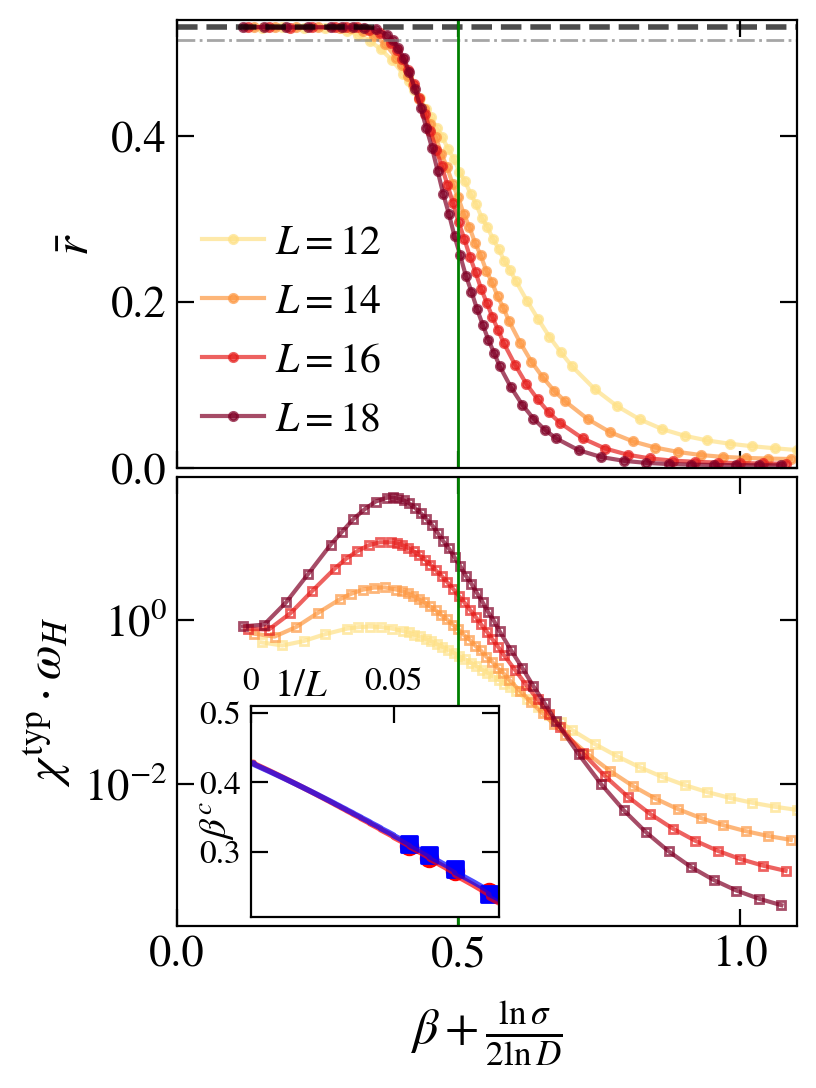

In [109]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
delta=0.55
op=0

RESCALE = 0
BC = 0
use_gap_or_weight = 1

prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
# prefix = '../results/disorder/OBC/Spectrals_SzSz_test/'
hz = 1 if BC else 0
if not BC: use_gap_or_weight = 1

sizes = np.arange(12, 17 if BC else 19, 2)

DIM = 1
fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,6), dpi = 200, sharex=True, sharey=False)

L = 15
eps = 0.5

dw = 0.04
wx_vals2 = np.sort( np.array([*np.arange(0.04, 1.01, 0.04), *np.arange(0.22, 0.61, 0.04), *np.arange(0.31, 0.51, 0.02)]) )
if BC:
    wx_vals2 = np.arange(0.0, 0.99, 0.02)
    # wx_vals2 = np.arange(0.2, 0.66, 0.05)

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.2, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])

r_cut = 0.515 if use_gap_or_weight else 0.18

agp_max = np.zeros(sizes.shape)
r_drift = np.zeros(sizes.shape)
AGPs = []
for iiL, L in enumerate(sizes):
    dim = int( binom(L, L//2) )

    col = s_m.to_rgba(L)
    wx_vals = wx_vals2
    gap_ratio = np.zeros(wx_vals.shape)
    agp = np.zeros(wx_vals.shape)
    realis = np.zeros(wx_vals.shape)
    
    sigma_num = np.zeros(wx_vals.shape)
    for iiw, wx in enumerate(wx_vals):
        
        name = prefix + info_dis(L=L, J1=J, delta1=delta, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                wH = np.array(file.get('wH'))[-2]
                Ex = np.array(file.get('average energies'))
                Eav = np.mean(Ex)
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - Eav))
                
                num = dim//2
                # num = min([500, dim//10])
                if L < 20: gap_ratio[iiw] = np.mean(np.array(file.get('gap_ratios'))[idx - num//2 : idx + num//2]) if use_gap_or_weight else 1-np.mean( np.array(file.get('weight_ratios'))[idx - num//2 : idx + num//2])
                else:      gap_ratio[iiw] = np.mean(np.array(file.get('gap_ratios'))) if use_gap_or_weight else 1-np.mean( np.array(file.get('weight_ratios')))
                # gap_ratio[iiw] = np.mean(np.array(file.get('gap_ratios'))) if use_gap_or_weight else 1-np.mean( np.array(file.get('weight_ratios')))
                # agp[iiL] = np.array(file.get('SUSC_R'))[-2] * wH
                agp[iiw] = np.array(file.get('TYP_SUSC_R'))[-2] * wH# if L < 20 else np.array(file.get('TYP_SUSC_R'))[-2] * wH
                # agp[iiw] = np.array(file.get('SUSC_R'))[-2] * wH
                # agp[iiw] = np.array(file.get('susc'))[0]
                
                realis[iiw] = np.array(file.get('realisations'))
                sigma_num[iiw] = np.mean( np.array(file.get('stddev')) )
                # sigma_num[iiw] = np.mean( np.array(file.get('bandwidth')) )
        else:
            print(name)
    
    gap_ratio = gap_ratio[~np.isinf(agp)]
    wx_vals = wx_vals[~np.isinf(agp)]
    agp = agp[~np.isinf(agp)]
    # print(L, agp)
    
    sigma = sigma_num#np.sqrt( (2 + delta**2 )/4 + dim**(-2*wx_vals) / 3) / 2 * np.sqrt(L)
    xx = binom(L, L//2)**(-wx_vals) if RESCALE else wx_vals + np.log(1/0.3413 * sigma) / (2*np.log( binom(L, L//2) ))
    
    axis[0].plot(xx, gap_ratio, color=col, marker='o', alpha=0.7, markersize=3, label=r"$L=%d$"%L)#, lw=0)
    if L < 20: axis[1].plot(xx, agp, color=col, markerfacecolor='None', marker='s', alpha=0.7, markersize=3)

    xx = wx_vals[wx_vals > 0.05]
    
    sigma = sigma_num[wx_vals > 0.05]#np.sqrt( (2 + delta**2 )/4 + dim**(-2*xx) / 3) / 2 * np.sqrt(L)
    # xx = xx + np.log(1/0.3413 * sigma) / (2*np.log( binom(L, L//2) ))
    yy = agp[wx_vals > 0.05]
    AGPs.append(yy)
    
    indices = np.arange( max([np.argmax(yy) - 5, 0]), min([np.argmax(yy) + 7,xx.size]), 1)
    x = np.linspace(xx[indices][0], xx[indices][-1], 1000)
    f = splrep(xx[indices], yy[indices], k=5, s=10)
    yy = splev(x, f)
    agp_max[iiL] = x[np.argmax(yy)]
    
    yy = gap_ratio[wx_vals > 0.05]
    idx = np.argmin(np.abs(yy - 0.515))
    indices = np.arange( max([idx - 5, 0]), min([idx + 10, xx.size]), 1)
    f = splrep(xx[indices], yy[indices], k=5, s=0)
    yy = splev(x, f)
    r_drift[iiL] = x[np.argmin(np.abs(yy - r_cut))]
    # axis[0].plot(x, yy, color=col, alpha=0.7)
    
# AGPs = np.array(AGPs)
# agp_cross = np.zeros( (sizes.size-1))    
# for iiL, L in enumerate(sizes[1:]):
#     xx = wx_vals[wx_vals > 0.1]
#     idx = np.argmin(np.abs(AGPs[iiL+1] - AGPs[iiL]))
#     indices = np.arange( max([idx - 10, 0]), min([idx + 7, xx.size]), 1)
#     x = np.linspace(xx[indices][0], xx[indices][-1], 1000)
#     yy1 = AGPs[iiL]
#     yy2 = AGPs[iiL+1]
#     f = splrep(xx[indices], yy1[indices], k=5, s=0)
#     yy1 = splev(x, f)
#     f = splrep(xx[indices], yy2[indices], k=5, s=0)
#     yy2 = splev(x, f)
#     agp_cross[iiL] = x[np.argmin(np.abs(yy2 - yy1))]
 
fig_help.set_plot_elements(axis[0], ylabel=r"$\bar{r}$" if use_gap_or_weight else r"$\bar{q}$", xlabel=r"", font_size=16, set_legend=0, xscale='log' if RESCALE else 'linear', yscale='linear')
fig_help.set_plot_elements(axis[1], ylabel=r"$\chi^{\rm typ}\cdot\omega_H$", xlabel=r"$w$" if RESCALE else r"$\beta+\frac{\ln\sigma}{2\ln{D}}$", font_size=16, set_legend=1, xscale='log' if RESCALE else 'linear', yscale='log')
fig_help.set_legend(axis[0], fontsize=15, loc='lower left')

axis[0].set_ylim(0.38 if BC else 0., 0.54)
if not use_gap_or_weight: axis[0].set_ylim(0., 0.2)
axis[0].axhline(y=0.5308, ls='--', color='k', lw=2, alpha=0.7)
axis[0].axhline(y=r_cut, ls='-.', color='gray', lw=1, alpha=0.7)
axis[0].axvline(x=0.5, ls='-', color='green', lw=1)
axis[1].axvline(x=0.5, ls='-', color='green', lw=1)

if not RESCALE: axis[0].set_xlim(0, 1.1)

inset = axis[1].inset_axes([0.12, 0.02, 0.4, 0.47])
# inset.scatter(1/sizes, agp_max, marker='o', color='red')
# inset.scatter(1/sizes, r_drift, marker='s', color='blue')
# inset.scatter(1/sizes[1:], agp_cross, marker='v', color='green')

def beta_c_fit(L, C, a):
    # return (np.log(2) - np.log(1/4**L * (C**2 * L + C * np.sqrt(L) * np.sqrt(4**(L+1) * a + C**2 * L)))) / (L * np.log(4))
    # return (np.log(2) - np.log(1/4**L * (C**2 * L**5 + C * np.sqrt(L**5) * np.sqrt(4**(L+1) * a + C**2 * L**5)))) / (L * np.log(4))
    # return 0.5 - C * np.exp(-a * L)
    return a + np.log(C) / (2*np.log( binom(L, L//2) ))# - np.log(np.sqrt( (2 + delta**2 )/4 + 2**(-2*L*xx) / 3) / 2 / 0.3413) / (2*np.log(binom(L, L//2)))
    # return 0.5 + np.log(C) / (2*np.log( binom(L, L//2) ))
    # return 0.5 + 1 / (2*L) - 1/2 * np.log(a * L) / (L * np.log(4))


LOG = 1
def plot_fit_inset(x, y, mar = 'o', col = 'red'):
    pars, pconv, fit_info, msg, _ = fit(beta_c_fit,
                        xdata = x[-2:],
                        ydata = y[-2:],
                        full_output=True, maxfev=10000)
    x_den = np.linspace(0, 1/(min(x)-1), 10000)
    # x_den = np.linspace(min(x)-1, max(x)+1, 10000)
    inset.scatter(1/x, y, marker=mar, color=col)
    inset.plot(x_den, beta_c_fit(1/x_den, *pars), color=col, ls='-', lw=2, alpha=0.7)
    # print(y, beta_c_fit(x, *pars))
    print(*pars)
    # inset.plot(x_den, )
plot_fit_inset(sizes[sizes<20], agp_max[sizes<20], mar='o', col='red')
plot_fit_inset(sizes, r_drift, mar='s', col='blue')
# inset.scatter(sizes[1:], agp_cross, marker='v', color='green')(1/sizes[1:], agp_cross, marker='v', color='green')

fig_help.set_plot_elements(inset, ylabel=r"$\beta^c$", xlabel=r"$1/L$", font_size=12, set_legend=True, xscale='linear', yscale='linear')
inset.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%x ))
inset.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%x ))

inset.xaxis.set_label_coords(0.2, 1.05)
inset.yaxis.set_label_coords(-0.06, 0.46)

inset.set_xlim(0, 1/(min(sizes)-0.5))
# inset.set_xlim(min(sizes)-0.5, max(sizes)+0.5)
inset.set_ylim(None, 0.51)

inset.xaxis.set_ticks_position('top')
inset.xaxis.set_label_position('top')
# inset.yaxis.set_ticks_position('right')
# inset.yaxis.set_label_position('right')

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

No handles with labels found to put in legend.


[0.05 0.09 0.13 0.17 0.21 0.25 0.29 0.33 0.37 0.41 0.45 0.49 0.53 0.57
 0.61 0.65 0.69 0.73 0.77 0.81 0.85 0.89 0.93]
[0.17351351351351352, 0.1, 0.1, 0.23671671671671676, 0.26810810810810815, 0.2823023023023023, 0.27569569569569574, 0.3081081081081081, 0.3162962962962963, 0.3324924924924925, 0.33949949949949954, 0.33949949949949954, 0.3439039039039039, 0.34150150150150155, 0.34190190190190195, 0.3330930930930931, 0.32590590590590596, 0.2980980980980981, 0.2805005005005005, 0.2750950950950951, 0.2821021021021021, 0.1, 0.1]


(0.05, 0.95)

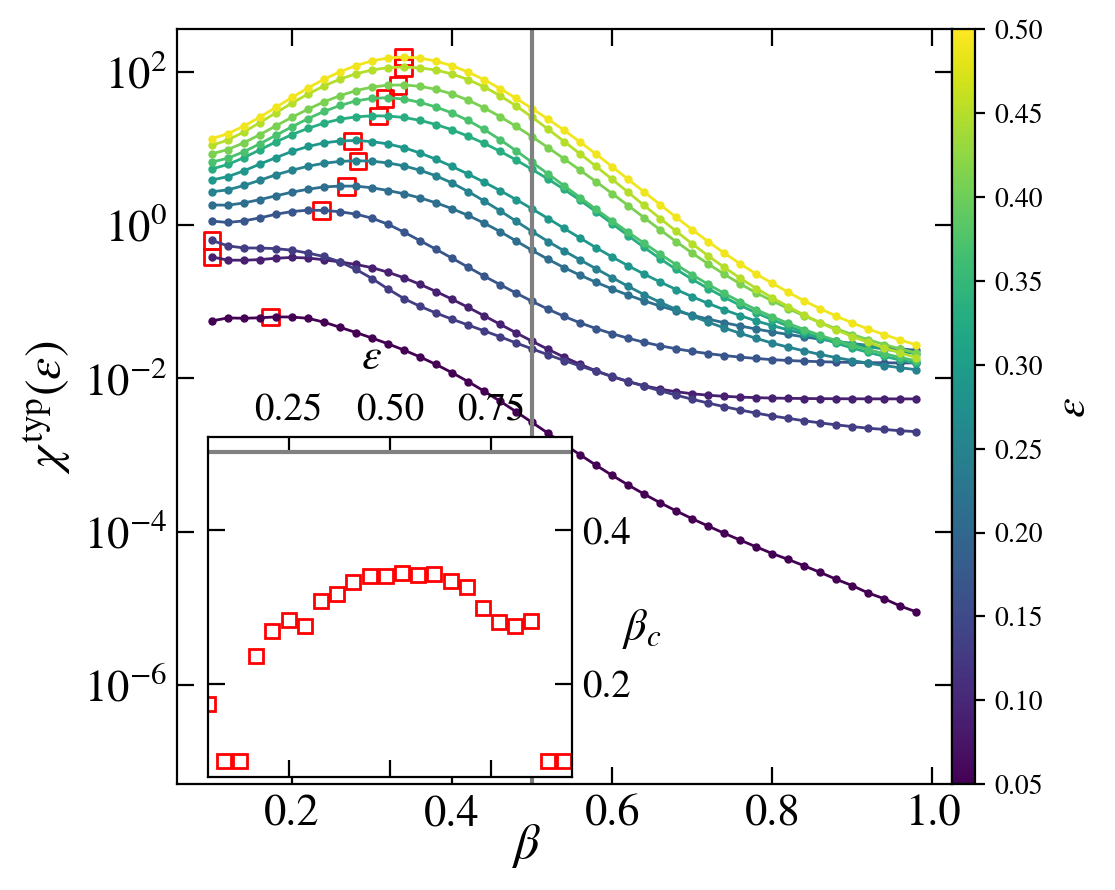

In [ ]:

L = 16
w = 2
J = 1
delta=0.55
op=0

BC = 1

prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
hz = 1 if BC else 0

sizes = np.arange(12, 18, 2)

wx_vals2 = np.arange(0.04, 1.01, 0.04)#np.sort( np.array([*np.arange(0.04, 1.01, 0.04), *np.arange(0.22, 0.61, 0.04), *np.arange(0.31, 0.51, 0.02)]) )
if BC:
    wx_vals2 = np.arange(0.1, 0.99, 0.02)


dim = 2**L
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)

inset = axis.inset_axes([0.04, 0.01, 0.47, 0.45])

depsilon = 0.05
_eps_ = np.arange(depsilon, 1.0-depsilon, 0.04)
_eps_ = _eps_[_eps_ <= 0.95]
_eps_ = _eps_[_eps_ >= 0.02]

s_m_a = matplotlib.cm.ScalarMappable(cmap='coolwarm', norm= matplotlib.colors.Normalize(vmin=min(wx_vals2), vmax=max(wx_vals2) ))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm= matplotlib.colors.Normalize(vmin=min(_eps_), vmax=0.5 ))
# s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm= matplotlib.colors.Normalize(vmin=0.5, vmax=max(_eps_) ))
s_m.set_array([])

alfa_c = []
alfa_c2 = []
agp_c = []
for jj in range(_eps_.size):
    eps = _eps_[jj]
    col2 = s_m.to_rgba(eps)
    # print(eps)
    agp      = np.zeros((wx_vals2.size)); agp.fill(np.nan)
    
    num = 20
    agp_GSinv   = np.zeros((num, wx_vals2.size)); agp_GSinv.fill(np.nan)
    for ii, wx in enumerate(wx_vals2):
        alfa = np.round(wx, 2)
        col = s_m_a.to_rgba(alfa)
        # eta = 2 / (2 - gx)
        name = prefix + info_dis(L=L, J1=J, delta1=delta, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                E = np.array(file.get('energy_density')) #[window//2:-window//2]
                wH = np.array(file.get('wH_density'))
                # print(E)
                
                R = np.array(file.get('realisations'))
                DOS = np.array(file.get('DOS'))
                DOS = DOS / max(DOS) * dim
                idx_05 = min(range(len(E)), key=lambda i: abs(E[i] - 0.5))
                idx2 = min(range(len(E)), key=lambda i: abs(E[i] - eps))
                
                norm = DOS
                
                count = np.array(file.get('count')) / R
                _agp = np.array(file.get('susc_E_typ')) / R
                
                # _agp = _agp / norm
                agp[ii] = _agp[idx2] / count[idx2]
        else:
            print(name)
    
    norm = dim#max(agp2)#matelem**2 / wH**2
    if eps <= 0.5:
        axis.plot(wx_vals2, agp, color=col2, marker='o', markersize=2, lw=1)
    
    idx = np.argmax(agp)
    
    # agp = agp[wx_vals2>0.1]
    x = wx_vals2#[wx_vals2>0.1]
    indices = np.arange(max(np.argmax(agp) - 5,0), min(np.argmax(agp) + 6, agp.size-1), 1)
    x = np.linspace(x[indices][0], x[indices][-1], 1000)
    f = splrep(wx_vals2[indices], agp[indices], k=3, s=5)
    agp = splev(x, f)
    idx = np.argmax(agp)
    alfa_c.append(x[idx])
    if eps <= 0.5:
        alfa_c2.append(x[idx])
        agp_c.append(agp[idx])
    
    # if eps <= 0.5:
    #     axis.plot(x, agp, color=col2, alpha=0.5)
    
    # if eps <= 0.5:
    #     axis.plot(x, agp, color=col2, lw=4, alpha=0.35)
print(_eps_)
print(alfa_c)
inset.plot(_eps_, alfa_c,  marker='s', color='red', ls='--', markersize=5, lw=0, markerfacecolor='None')#, label=r"$L=%d$"%(L))
# z = np.linspace(0, 1, 1000)
# inset.plot(z, 2 - 8 * (z - 0.5)**2, ls='--', color='k')
# a = 1.05
# b = 0.45
# alfac = g_crit#1 / np.sqrt(2)
# x = np.linspace(0.13, 0.87, 1000)
# inset.plot(x, alfac * np.exp(a**2 * (x - 0.5)**2 / 4 / b*2), color='k', ls='--', lw=2, label=r"$L=\infty$")
axis.scatter(alfa_c2, agp_c, marker='s', color='red', facecolor='None')

axis.xaxis.set_label_coords(.45, -0.05)

axis.axvline(x=0.5, ls='-', c='gray')
# axis.axvline(x=alfa_crit,    ls=':', c='k')
# axis.set_xlim(0, 1)
ylab = r"$\chi^{\rm typ}(\epsilon)$"
fig_help.set_plot_elements(axis, ylabel=ylab, xlabel=r"$\beta$", font_size=16, set_legend=False, xscale='linear', yscale='log')
axis.set_ylim(5e-8, None)


cbar_ax = axis.inset_axes([1., 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$\epsilon$", fontsize=16)
cbar_ax.yaxis.set_ticks_position('right')
cbar_ax.yaxis.set_label_position('right')

inset.xaxis.set_label_position("top")
inset.xaxis.set_label_coords(.45, 1.2)
inset.xaxis.tick_top()

inset.yaxis.set_label_position("right")
# inset.yaxis.set_label_coords(1.24, 0.59)
inset.yaxis.tick_right()
fig_help.set_plot_elements(inset, ylabel=r"$\\beta_c^*$", xlabel=r"$\epsilon$", font_size=14, set_legend=False, xscale='linear', yscale='linear')
fig_help.set_legend(inset, fontsize=12, loc='lower center')

# inset.set_yticks([1, 1.2, 1.4, 1.6, 1.8, 2.0])

inset.set_ylabel(r"$\beta_c$", rotation=0, fontsize=16)

inset.axhline(y=0.5,    ls='-', color='gray')
# inset.axhline(y=2, ls='-', color='gray')
# inset.set_ylim(0.0, 2.05)
inset.set_xlim(0.05, 0.95)

# fig.savefig("PLOTS_FADING/Fig_max_chaos_mobility.pdf", bbox_inches = 'tight', pad_inches=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


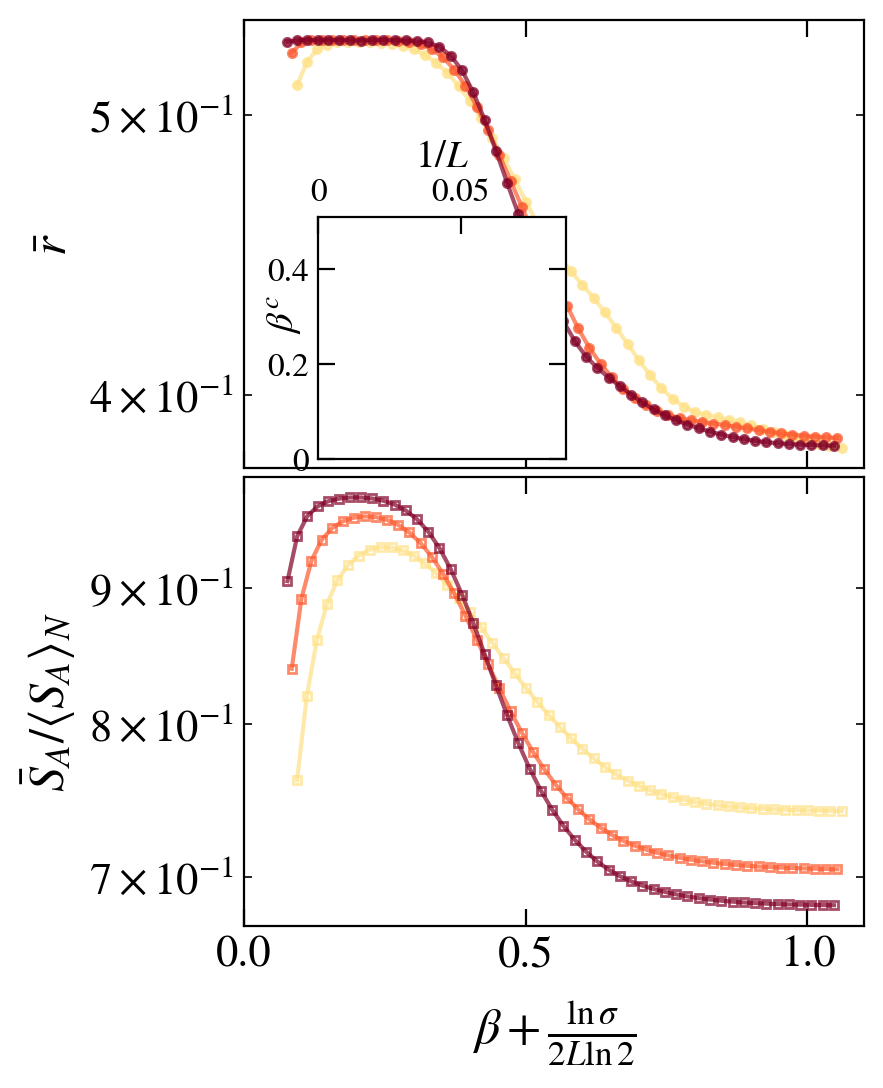

In [54]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
delta=0.55
op=0

BC = 1
use_gap_or_weight = 1

prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
# prefix = '../results/disorder/OBC/Spectrals_SzSz_test/'
hz = 1 if BC else 0
if not BC: use_gap_or_weight = 1

sizes = np.arange(12, 17 if BC else 19, 2)

DIM = 1
fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,6), dpi = 200, sharex=True, sharey=False)

L = 15
eps = 0.5

dw = 0.04
wx_vals2 = np.sort( np.array([*np.arange(0.04, 1.01, 0.04), *np.arange(0.22, 0.61, 0.04), *np.arange(0.31, 0.51, 0.02)]) )
if BC:
    wx_vals2 = np.arange(0.0, 0.99, 0.02)
    # wx_vals2 = np.arange(0.2, 0.66, 0.05)

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.2, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])

r_cut = 0.515 if use_gap_or_weight else 0.18

agp_max = np.zeros(sizes.shape)
r_drift = np.zeros(sizes.shape)
AGPs = []
for iiL, L in enumerate(sizes):
    dim = int( binom(L, L//2) )

    col = s_m.to_rgba(L)
    wx_vals = wx_vals2
    
    LA = 2
    gap_ratio = np.zeros(wx_vals.shape)
    SA = np.zeros(wx_vals.shape)
    realis = np.zeros(wx_vals.shape)
    
    sigma_num = np.zeros(wx_vals.shape)
    for iiw, wx in enumerate(wx_vals):
        
        name = prefix + info_dis(L=L, J1=J, delta1=delta, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                wH = np.array(file.get('wH_typ'))[-2]
                Ex = np.array(file.get('average energies'))
                Eav = np.mean(Ex)
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - Eav))
                
                num = dim//2
                # num = min([500, dim//10])
                if L < 20: gap_ratio[iiw] = np.mean(np.array(file.get('gap_ratios'))[idx - num//2 : idx + num//2]) if use_gap_or_weight else 1-np.mean( np.array(file.get('weight_ratios'))[idx - num//2 : idx + num//2])
                else:      gap_ratio[iiw] = np.mean(np.array(file.get('gap_ratios'))) if use_gap_or_weight else 1-np.mean( np.array(file.get('weight_ratios')))
                SA[iiw] = np.mean(np.array(file.get('entropies'))[L//2].flatten()) / page_U1(L//2, L//2, L//2)
            
                realis[iiw] = np.array(file.get('realisations'))
                sigma_num[iiw] = np.mean( np.array(file.get('stddev')) )
        else:
            print(name)
    
    gap_ratio = gap_ratio[~np.isinf(SA)]
    wx_vals = wx_vals[~np.isinf(SA)]
    SA = SA[~np.isinf(SA)]
    # print(L, agp)
    
    sigma = sigma_num#np.sqrt( (2 + delta**2 )/4 + dim**(-2*wx_vals) / 3) / 2 * np.sqrt(L)
    axis[0].plot(wx_vals + np.log(1/0.3413 * sigma) / (2*L*np.log(2)), gap_ratio, color=col, marker='o', alpha=0.7, markersize=3)#, lw=0)
    axis[1].plot(wx_vals + np.log(1/0.3413 * sigma) / (2*L*np.log(2)), SA, color=col, markerfacecolor='None', marker='s', alpha=0.7, markersize=3)

    # xx = wx_vals[wx_vals > 0.05]
    
    # sigma = sigma_num[wx_vals > 0.05]#np.sqrt( (2 + delta**2 )/4 + dim**(-2*xx) / 3) / 2 * np.sqrt(L)
    # xx = xx + np.log(1/0.3413 * sigma) / (2*L*np.log(2))
    # yy = agp[wx_vals > 0.05]
    # AGPs.append(yy)
    
    # indices = np.arange( max([np.argmax(yy) - 5, 0]), min([np.argmax(yy) + 7,xx.size]), 1)
    # x = np.linspace(xx[indices][0], xx[indices][-1], 1000)
    # f = splrep(xx[indices], yy[indices], k=5, s=10)
    # yy = splev(x, f)
    # agp_max[iiL] = x[np.argmax(yy)]
    
    # yy = s[wx_vals > 0.05]
    # idx = np.argmin(np.abs(yy - 0.515))
    # indices = np.arange( max([idx - 5, 0]), min([idx + 10, xx.size]), 1)
    # f = splrep(xx[indices], yy[indices], k=5, s=0)
    # yy = splev(x, f)
    # r_drift[iiL] = x[np.argmin(np.abs(yy - r_cut))]
    # # axis[0].plot(x, yy, color=col, alpha=0.7)
    
# AGPs = np.array(AGPs)
# agp_cross = np.zeros( (sizes.size-1))    
# for iiL, L in enumerate(sizes[1:]):
#     xx = wx_vals[wx_vals > 0.1]
#     idx = np.argmin(np.abs(AGPs[iiL+1] - AGPs[iiL]))
#     indices = np.arange( max([idx - 10, 0]), min([idx + 7, xx.size]), 1)
#     x = np.linspace(xx[indices][0], xx[indices][-1], 1000)
#     yy1 = AGPs[iiL]
#     yy2 = AGPs[iiL+1]
#     f = splrep(xx[indices], yy1[indices], k=5, s=0)
#     yy1 = splev(x, f)
#     f = splrep(xx[indices], yy2[indices], k=5, s=0)
#     yy2 = splev(x, f)
#     agp_cross[iiL] = x[np.argmin(np.abs(yy2 - yy1))]
 
fig_help.set_plot_elements(axis[0], ylabel=r"$\bar{r}$", xlabel=r"", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$\bar{S}_A/\langle S_A\rangle_N$", xlabel=r"$\beta+\frac{\ln\sigma}{2L\ln{2}}$", font_size=16, set_legend=1, xscale='linear', yscale='log')
# axis[0].set_ylim(0.38 if BC else 0., 0.54)
# if not use_gap_or_weight: axis[0].set_ylim(0., 0.2)
# axis[0].axhline(y=0.5308, ls='--', color='k', lw=2, alpha=0.7)
# axis[0].axhline(y=r_cut, ls='-.', color='gray', lw=1, alpha=0.7)
# # axis[0].axhline(y=2*np.log(2)-1, ls=':', color='k', lw=2)
axis[0].set_xlim(0, 1.1)

inset = axis[0].inset_axes([0.12, 0.02, 0.4, 0.54])
# inset.scatter(1/sizes, agp_max, marker='o', color='red')
# inset.scatter(1/sizes, r_drift, marker='s', color='blue')
# inset.scatter(1/sizes[1:], agp_cross, marker='v', color='green')

def beta_c_fit(L, C, a):
    # return (np.log(2) - np.log(1/4**L * (C**2 * L + C * np.sqrt(L) * np.sqrt(4**(L+1) * a + C**2 * L)))) / (L * np.log(4))
    # return (np.log(2) - np.log(1/4**L * (C**2 * L**5 + C * np.sqrt(L**5) * np.sqrt(4**(L+1) * a + C**2 * L**5)))) / (L * np.log(4))
    # return 0.5 - C * np.exp(-a * L)
    return a + np.log(C) / (2*L*np.log(2))# - np.log(np.sqrt( (2 + delta**2 )/4 + 2**(-2*L*xx) / 3) / 2 / 0.3413) / (2*L*np.log(2))
    # return 0.5 - np.log(C) / (2*L*np.log(2))
    # return 0.5 + 1 / (2*L) - 1/2 * np.log(a * L) / (L * np.log(4))


# LOG = 1
# def plot_fit_inset(x, y, mar = 'o', col = 'red'):
#     pars, pconv, fit_info, msg, _ = fit(beta_c_fit,
#                         xdata = x[1:],
#                         ydata = y[1:],
#                         full_output=True, maxfev=10000)
#     x_den = np.linspace(0, 1/(min(x)-1), 10000)
#     # x_den = np.linspace(min(x)-1, max(x)+1, 10000)
#     inset.scatter(1/x, y, marker=mar, color=col)
#     inset.plot(x_den, beta_c_fit(1/x_den, *pars), color=col, ls='-', lw=2, alpha=0.7)
#     # print(y, beta_c_fit(x, *pars))
#     print(*pars)
#     # inset.plot(x_den, )
# plot_fit_inset(sizes[sizes<20], agp_max[sizes<20], mar='o', col='red')
# plot_fit_inset(sizes, r_drift, mar='s', col='blue')
# # inset.scatter(sizes[1:], agp_cross, marker='v', color='green')(1/sizes[1:], agp_cross, marker='v', color='green')

fig_help.set_plot_elements(inset, ylabel=r"$\beta^c$", xlabel=r"$1/L$", font_size=12, set_legend=True, xscale='linear', yscale='linear')
inset.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%x ))
inset.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%x ))

# inset.xaxis.set_label_coords(0.4, 1.05)
inset.yaxis.set_label_coords(-0.06, 0.6)

inset.set_xlim(0, 1/(min(sizes)-0.5))
# inset.set_xlim(min(sizes)-0.5, max(sizes)+0.5)
inset.set_ylim(None, 0.51)

inset.xaxis.set_ticks_position('top')
inset.xaxis.set_label_position('top')
# inset.yaxis.set_ticks_position('right')
# inset.yaxis.set_label_position('right')

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


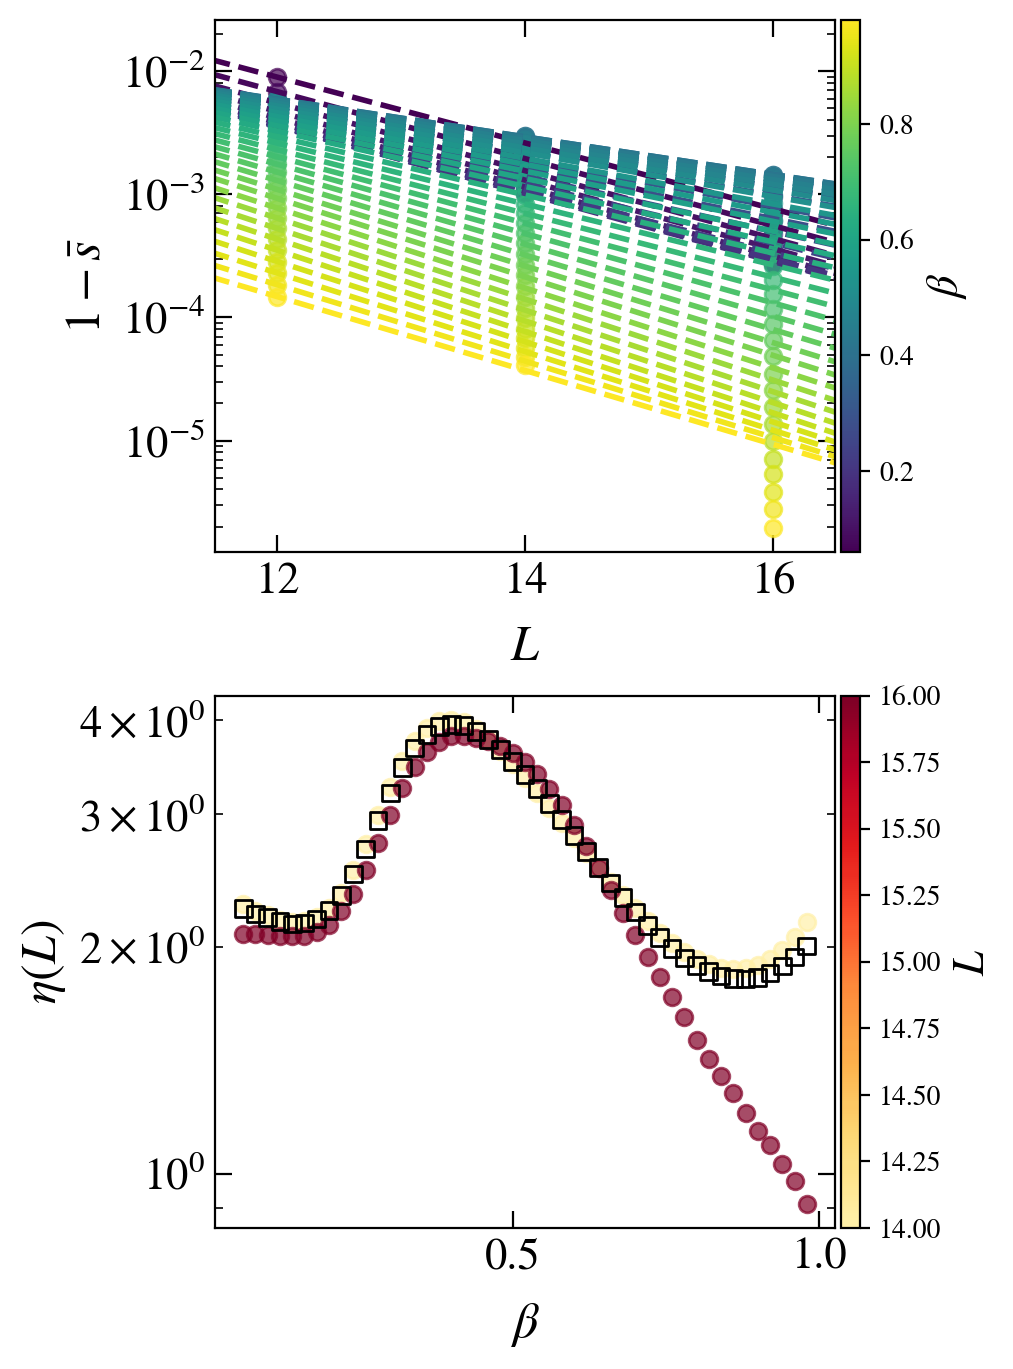

In [45]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

use_gap_or_weight = 0
BC = 1

prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
hz = 1 if BC else 0
if not BC: use_gap_or_weight = 1

sizes = np.arange(12, 18 if BC else 19, 2)

DIM = 1
fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,8), dpi = 200)


r_idx = 5
corr = 0
gx = 1.5
window = 40

L = 15
eps = 0.5

def exp_fit_kurwa(x, a, xi):
    """Exponential function to fit and find decay rate"""
    return a * 2**(-x * xi)
    # return 1 - 1 / (1 + a * 2**(-x * xi))

wx_vals = np.arange(0.06, 0.99, 0.02) if BC else np.sort( np.array([*np.arange(0.12, 1.0, 0.04), *np.arange(0.22, 0.61, 0.04), *np.arange(0.31, 0.51, 0.02)]) )

norm = matplotlib.colors.Normalize(
        vmin=min(wx_vals),
        vmax=max(wx_vals))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

etas = []
etas_fit = []
for ibsifusdf, wx in enumerate(wx_vals):
    col = s_m.to_rgba(wx)
    
    s = np.zeros(sizes.shape)
    realis = np.zeros(sizes.shape)
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    for iiL, L in enumerate(sizes):
        dim = int( binom(L, L//2) )
        counter = 0
        r = 0#np.zeros((45))
        
        name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('average energies'))
                Eav = np.mean(Ex)
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - Eav))
                # num = min([dim//10, 500])
                num = int(dim//2)
                # gap_ratio[iiL] = np.mean( np.array(file.get('gap_ratios'))[idx - num//2 : idx + num//2]) if use_gap_or_weight else np.mean( np.array(file.get('weight_ratios'))[idx - num//2 : idx + num//2])
                s[iiL] = 1 - np.mean(np.array(file.get('single_site_entropy'))[L//2].flatten()) / np.log(2)
                
                realis[iiL] = np.array(file.get('realisations'))
        else:
            print(name)
    
    # print(wx, realis, gap_ratio)
    yy = s
    # print(gx, sizes, yy)
    parsolo, pconv, fit_info, msg, _ = fit(exp_fit_kurwa,
                    xdata = sizes,
                    ydata = yy,
                    full_output=True, maxfev=20000)
    A = parsolo[0]
    eta_fit = 2 / parsolo[1]
    if eta_fit > 1e6:
        eta_fit = np.nan
    etas_fit.append(eta_fit)
    # if (iig == 0 and gx > 1.0) or (iig and gx < 4):
    z = np.linspace(min(sizes)-1, max(sizes)+1, 1000)
    axis[0].plot(z, exp_fit_kurwa(z, *parsolo), color=col, ls='--', lw=2)
    axis[0].scatter(sizes, yy, color=col, alpha=0.7)
    
    eta = 2 / (np.diff( np.log(yy) ) / np.diff(sizes) / np.log(2))
    etas.append(eta)
    
cbar_ax = axis[0].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$\beta$", fontsize=16)
# cbar_ax.xaxis.set_ticks_position('top')
# cbar_ax.xaxis.set_label_position('top')

etas_fit = np.array(etas_fit)
etas = np.transpose(np.array(etas))

norm = matplotlib.colors.Normalize(vmin=min(sizes[1:]), vmax=max(sizes[1:]) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])
for iiL, L in enumerate(sizes[1:]):
    col = s_m.to_rgba(L)
    axis[1].scatter(wx_vals, np.abs(etas[iiL]), color=col, marker='o', facecolor=col, alpha=0.7)  

axis[1].scatter(wx_vals, np.abs(etas_fit), color='k', marker='s', facecolor='None')


axis[0].set_xlim(min(sizes)-0.5, max(sizes)+0.5)

cbar_ax = axis[1].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$L$", fontsize=16)

# ax.set_ylim(0, 1.05)

# z = np.linspace(1.0, 3.01, 1000)
# ax.plot(z, 2/np.abs(2 - z), ls='-.', color='blue')
# ax.set_ylim(1, 3e2)
# z = np.linspace(0.5, 1.0, 1000)
# ax.plot(z, [1]*z.size, ls='-.', color='blue')
# # ax[1].scatter(gamma_vals, 1/(etas_NE / np.log(2)), color='red', marker='s', facecolor='None')

fig_help.set_plot_elements(axis[0], ylabel=r"$1-\bar{s}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
# fig_help.set_plot_elements(axis[1], ylabel=r"$\bar{r} - r_{\rm PE}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$\eta(L)$", xlabel=r"$\beta$", font_size=16, set_legend=1, xscale='linear', yscale='log')


fig.subplots_adjust(wspace = 0.27, hspace=0.27)

## DIAGONAL MATRIX ELEMENTS

No handles with labels found to put in legend.
No handles with labels found to put in legend.


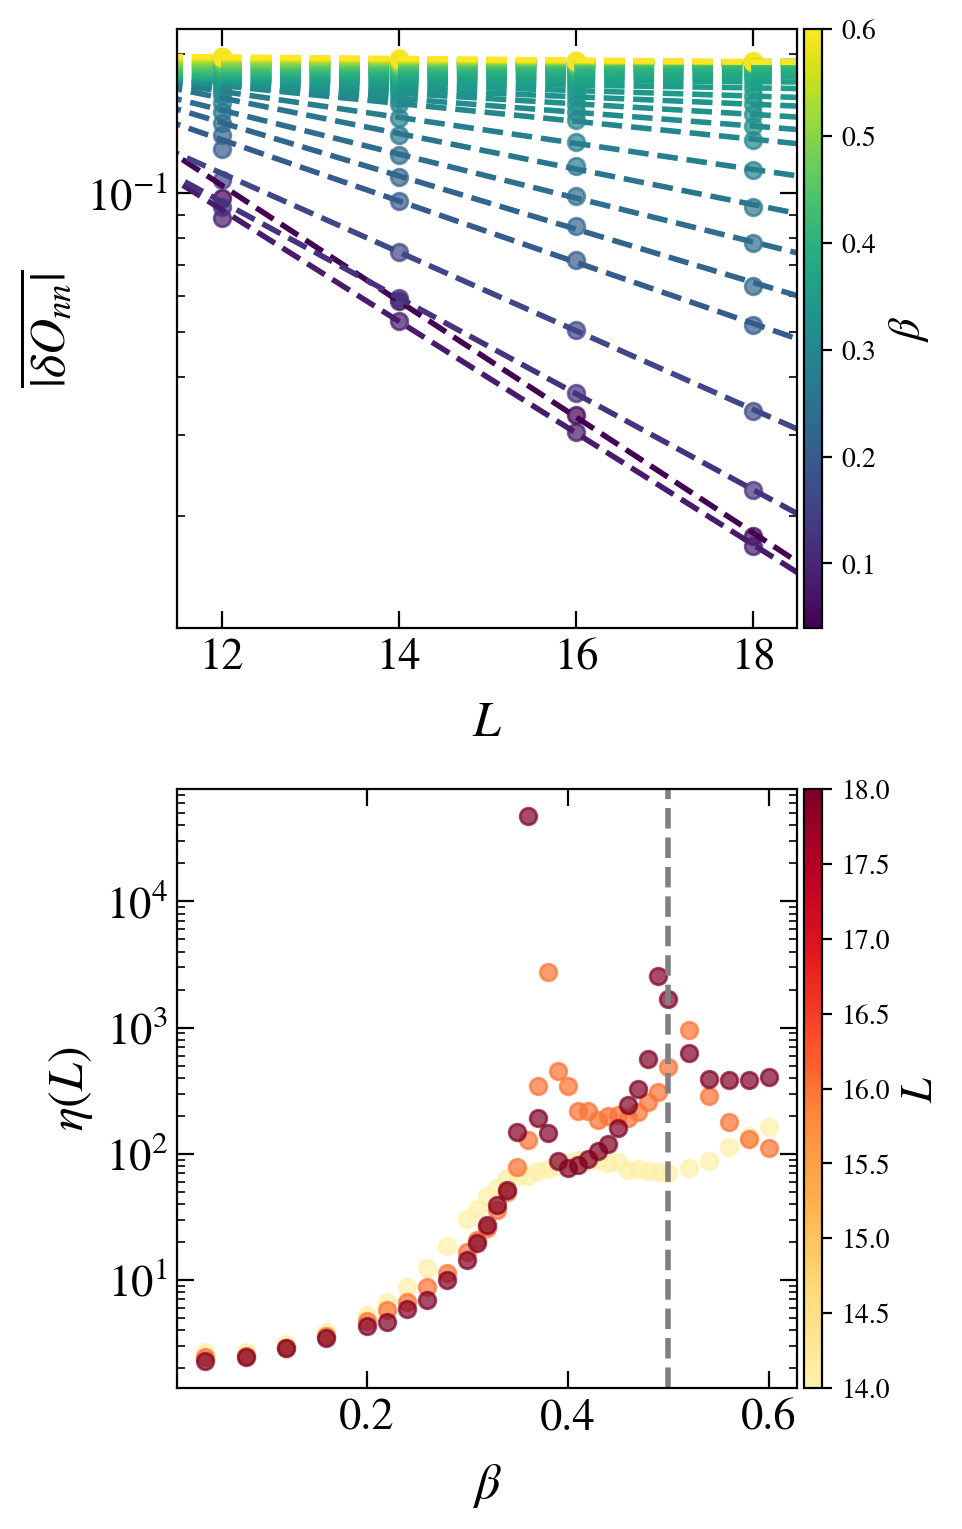

In [113]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

BC = 0

prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
hz = 1 if BC else 0

sizes = np.arange(12, 17 if BC else 19, 2)

DIM = 1
fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,9), dpi = 200)


r_idx = 5
corr = 0
gx = 1.5
window = 40

L = 15
eps = 0.5

def exp_fit_kurwa(x, a, xi):
    """Exponential function to fit and find decay rate"""
    return a * 2**(-x * xi)
    # return 1 - 1 / (1 + a * 2**(-x * xi))

wx_vals = np.arange(0.02, 0.71, 0.02) if BC else np.sort( np.array([*np.arange(0.04, 0.61, 0.04), *np.arange(0.22, 0.61, 0.04), *np.arange(0.31, 0.51, 0.02)]) )

# wx_vals = np.arange(0.36, 0.61, 0.02)

norm = matplotlib.colors.Normalize(
        vmin=min(wx_vals),
        vmax=max(wx_vals))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

etas = []
etas_fit = []
for ibsifusdf, wx in enumerate(wx_vals):
    col = s_m.to_rgba(wx)
    
    e_to_e_fluct = np.zeros(sizes.shape)
    realis = np.zeros(sizes.shape)
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    for iiL, L in enumerate(sizes):
        dim = int( binom(L, L//2) )
        counter = 0
        r = 0#np.zeros((45))
        
        name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energy_density'))
                DOS = np.array(file.get('DOS'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                
                realis[iiL] = np.array(file.get('realisations'))
                e_to_e_fluct[iiL] = np.array(file.get('e_to_e_fluct'))[-1] if L < 20 else np.array(file.get('e_to_e_fluct'))[-1]
                
        else:
            print(name)
    
    # print(wx, realis, gap_ratio)
    yy = e_to_e_fluct
    # print(gx, sizes, yy)
    parsolo, pconv, fit_info, msg, _ = fit(exp_fit_kurwa,
                    xdata = sizes[1:],
                    ydata = yy[1:],
                    full_output=True, maxfev=10000)
    A = parsolo[0]
    eta_fit = 1 / parsolo[1]
    if eta_fit > 1e6:
        eta_fit = np.nan
    etas_fit.append(eta_fit)
    # if (iig == 0 and gx > 1.0) or (iig and gx < 4):
    z = np.linspace(min(sizes)-1, max(sizes)+1, 1000)
    axis[0].plot(z, exp_fit_kurwa(z, *parsolo), color=col, ls='--', lw=2)
    axis[0].scatter(sizes, yy, color=col, alpha=0.7)
    
    eta = 1 / (np.diff( np.log(e_to_e_fluct) ) / np.diff(sizes) / np.log(2))
    etas.append(eta)
    
cbar_ax = axis[0].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$\beta$", fontsize=16)
# cbar_ax.xaxis.set_ticks_position('top')
# cbar_ax.xaxis.set_label_position('top')

etas_fit = np.array(etas_fit)
etas = np.transpose(np.array(etas))

norm = matplotlib.colors.Normalize(vmin=min(sizes[1:]), vmax=max(sizes[1:]) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)


s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])
for iiL, L in enumerate(sizes[1:]):
    col = s_m.to_rgba(L)
    # axis[1].scatter(2**(-L*wx_vals), np.abs(etas[iiL]), color=col, marker='o', facecolor=col, alpha=0.7)  
    axis[1].scatter(wx_vals, np.abs(etas[iiL]), color=col, marker='o', facecolor=col, alpha=0.7)  

# axis[1].scatter(wx_vals, np.abs(etas_fit), color='k', marker='s', facecolor='None')


axis[0].set_xlim(min(sizes)-0.5, max(sizes)+0.5)

cbar_ax = axis[1].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$L$", fontsize=16)

axis[1].axvline(x=0.5, ls='--', color='gray', lw=2)
# ax.set_ylim(0, 1.05)

# z = np.linspace(1.0, 3.01, 1000)
# ax.plot(z, 2/np.abs(2 - z), ls='-.', color='blue')
# ax.set_ylim(1, 3e2)
# z = np.linspace(0.5, 1.0, 1000)
# ax.plot(z, [1]*z.size, ls='-.', color='blue')
# # ax[1].scatter(gamma_vals, 1/(etas_NE / np.log(2)), color='red', marker='s', facecolor='None')

fig_help.set_plot_elements(axis[0], ylabel=r"$\overline{|\delta O_{nn}|}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
# fig_help.set_plot_elements(axis[1], ylabel=r"$\bar{r} - r_{\rm PE}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$\eta(L)$", xlabel=r"$\beta$", font_size=16, set_legend=1, xscale='linear', yscale='log')


fig.subplots_adjust(wspace = 0.27, hspace=0.27)

No handles with labels found to put in legend.


../results/disorder/OBC/Spectrals_SzSz/_L=18,J1=1,J2=0,d1=0.55,d2=0,hz=1,w=0.4,pb=0.hdf5


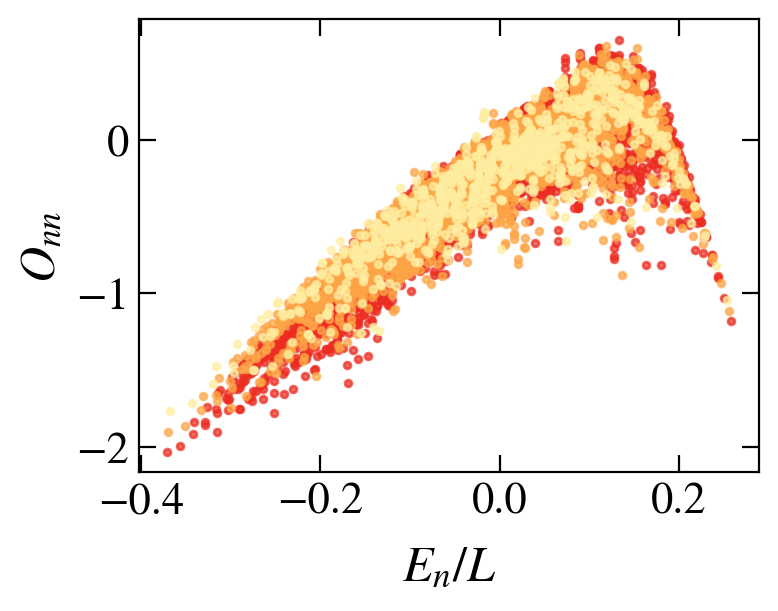

In [20]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

BC = 1

prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
hz = 1 if BC else 0

sizes = np.arange(12, 19, 2)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)

L = 15
eps = 0.5


norm = matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.12, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])


wx = 0.4
for iiL, L in enumerate(sizes[::-1]):
    dim = int( binom(L, L//2) )

    col = s_m.to_rgba(L)
    
    omegas = np.nan
    spec_fun = np.nan
    name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
    if exists(name):
        with h5py.File(name, "r") as file:
            Ex = np.array(file.get('energy_density'))
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
            DOS = np.array(file.get('DOS'))[idx]
            wH = np.array(file.get('wH'))[0]
            
            Ex = np.array(file.get('average energies'))
            # Ex = Ex - np.mean(Ex)
            diag_mat = np.array(file.get('diag_mat'))
            
            realis = np.array(file.get('realisations'))
            axis.scatter(Ex / L, diag_mat, color=col, alpha=0.7, s=6)
    else:
        print(name)
    
    
fig_help.set_plot_elements(axis, ylabel=r"$O_{nn}$", xlabel=r"$E_n/L$", font_size=16, set_legend=1, xscale='linear', yscale='linear')


fig.subplots_adjust(wspace = 0.02, hspace=0.02)

## SPECTRAL STATISTICS

No handles with labels found to put in legend.
No handles with labels found to put in legend.


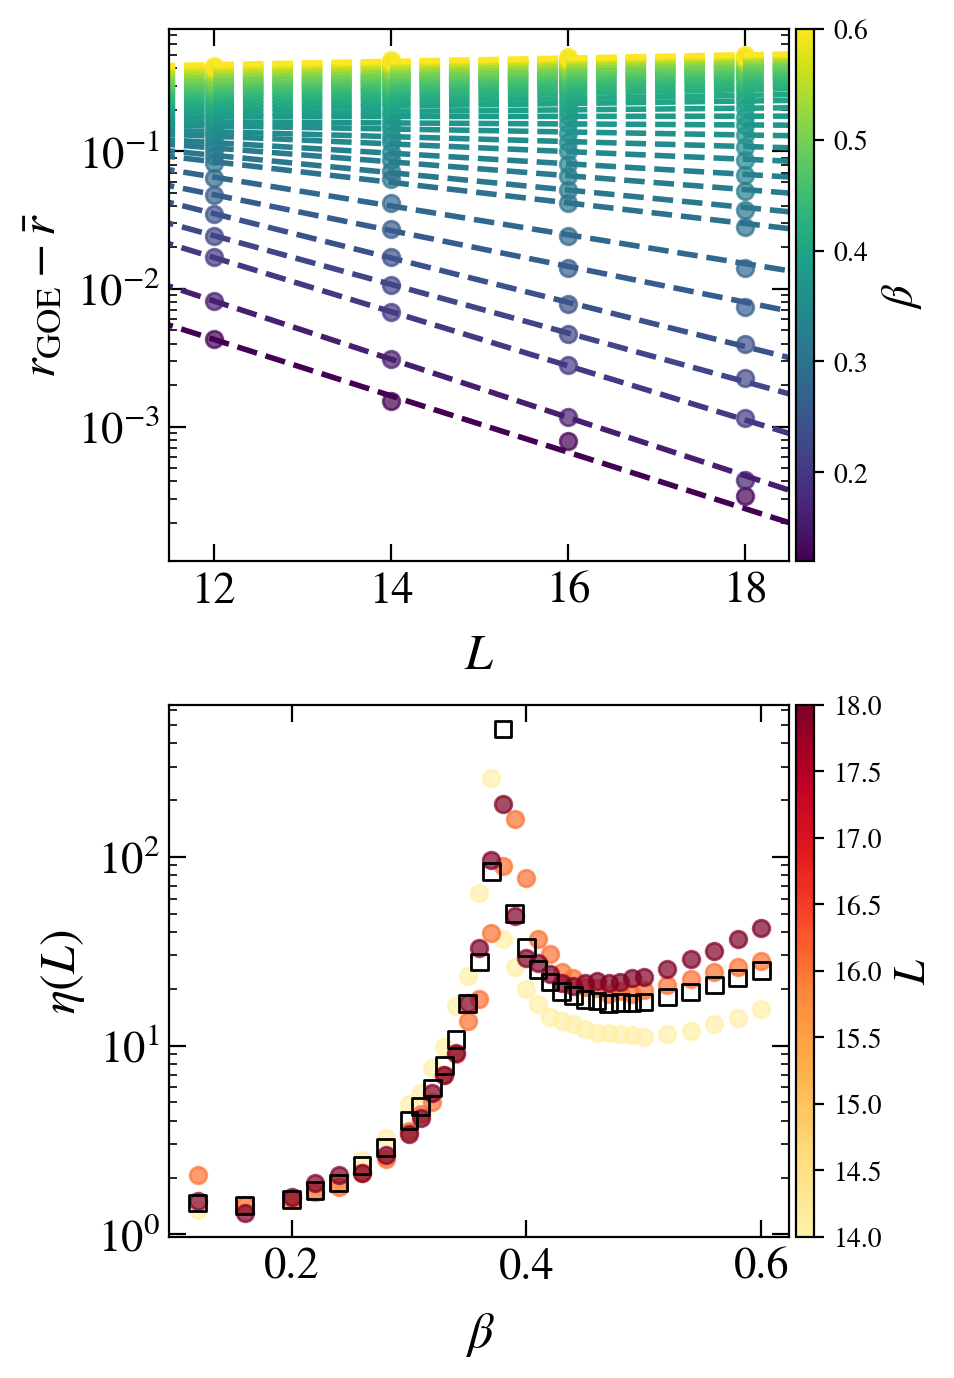

In [111]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

use_gap_or_weight = 1
BC = 0

prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
hz = 1 if BC else 0
if not BC: use_gap_or_weight = 1

sizes = np.arange(12, 18 if BC else 19, 2)

DIM = 1
fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,8), dpi = 200)


r_idx = 5
corr = 0
gx = 1.5
window = 40

L = 15
eps = 0.5

def exp_fit_kurwa(x, a, xi):
    """Exponential function to fit and find decay rate"""
    return a * 2**(-x * xi)
    # return 1 - 1 / (1 + a * 2**(-x * xi))

wx_vals = np.arange(0.06, 0.53, 0.02) if BC else np.sort( np.array([*np.arange(0.12, 0.61, 0.04), *np.arange(0.22, 0.61, 0.04), *np.arange(0.31, 0.51, 0.02)]) )

norm = matplotlib.colors.Normalize(
        vmin=min(wx_vals),
        vmax=max(wx_vals))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

etas = []
etas_fit = []
for ibsifusdf, wx in enumerate(wx_vals):
    col = s_m.to_rgba(wx)
    
    gap_ratio = np.zeros(sizes.shape)
    realis = np.zeros(sizes.shape)
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    for iiL, L in enumerate(sizes):
        dim = int( binom(L, L//2) )
        counter = 0
        r = 0#np.zeros((45))
        
        name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('average energies'))
                Eav = np.mean(Ex)
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - Eav))
                # num = min([dim//10, 500])
                num = int(dim//2)
                # gap_ratio[iiL] = np.mean( np.array(file.get('gap_ratios'))[idx - num//2 : idx + num//2]) if use_gap_or_weight else np.mean( np.array(file.get('weight_ratios'))[idx - num//2 : idx + num//2])
                gap_ratio[iiL] = np.mean( np.array(file.get('gap_ratios'))) if use_gap_or_weight else np.mean( np.array(file.get('weight_ratios')))
                
                realis[iiL] = np.array(file.get('realisations'))
        else:
            print(name)
    
    # print(wx, realis, gap_ratio)
    yy = 0.5307 - gap_ratio if use_gap_or_weight else gap_ratio - 0.8100699350 # if wx <= 0.5 else gap_ratio - (2*np.log(2) - 1)
    # print(gx, sizes, yy)
    parsolo, pconv, fit_info, msg, _ = fit(exp_fit_kurwa,
                    xdata = sizes,
                    ydata = yy,
                    full_output=True, maxfev=20000)
    A = parsolo[0]
    eta_fit = 1 / parsolo[1]
    if eta_fit > 1e6:
        eta_fit = np.nan
    etas_fit.append(eta_fit)
    # if (iig == 0 and gx > 1.0) or (iig and gx < 4):
    z = np.linspace(min(sizes)-1, max(sizes)+1, 1000)
    axis[0].plot(z, exp_fit_kurwa(z, *parsolo), color=col, ls='--', lw=2)
    axis[0].scatter(sizes, yy, color=col, alpha=0.7)
    
    eta = 1 / (np.diff( np.log(yy) ) / np.diff(sizes) / np.log(2))
    etas.append(eta)
    
cbar_ax = axis[0].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$\beta$", fontsize=16)
# cbar_ax.xaxis.set_ticks_position('top')
# cbar_ax.xaxis.set_label_position('top')

etas_fit = np.array(etas_fit)
etas = np.transpose(np.array(etas))

norm = matplotlib.colors.Normalize(vmin=min(sizes[1:]), vmax=max(sizes[1:]) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])
for iiL, L in enumerate(sizes[1:]):
    col = s_m.to_rgba(L)
    axis[1].scatter(wx_vals, np.abs(etas[iiL]), color=col, marker='o', facecolor=col, alpha=0.7)  

axis[1].scatter(wx_vals, np.abs(etas_fit), color='k', marker='s', facecolor='None')


axis[0].set_xlim(min(sizes)-0.5, max(sizes)+0.5)

cbar_ax = axis[1].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$L$", fontsize=16)

# ax.set_ylim(0, 1.05)

# z = np.linspace(1.0, 3.01, 1000)
# ax.plot(z, 2/np.abs(2 - z), ls='-.', color='blue')
# ax.set_ylim(1, 3e2)
# z = np.linspace(0.5, 1.0, 1000)
# ax.plot(z, [1]*z.size, ls='-.', color='blue')
# # ax[1].scatter(gamma_vals, 1/(etas_NE / np.log(2)), color='red', marker='s', facecolor='None')

fig_help.set_plot_elements(axis[0], ylabel=r"$r_{\rm GOE}-\bar{r}$" if use_gap_or_weight else r"$\bar{q} - q_{\rm GOE}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
# fig_help.set_plot_elements(axis[1], ylabel=r"$\bar{r} - r_{\rm PE}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$\eta(L)$", xlabel=r"$\beta$", font_size=16, set_legend=1, xscale='linear', yscale='log')


fig.subplots_adjust(wspace = 0.27, hspace=0.27)

(43, 49) (43, 49) (49, 43)


Text(0.5, 1.0, '$\\langle r\\rangle$')

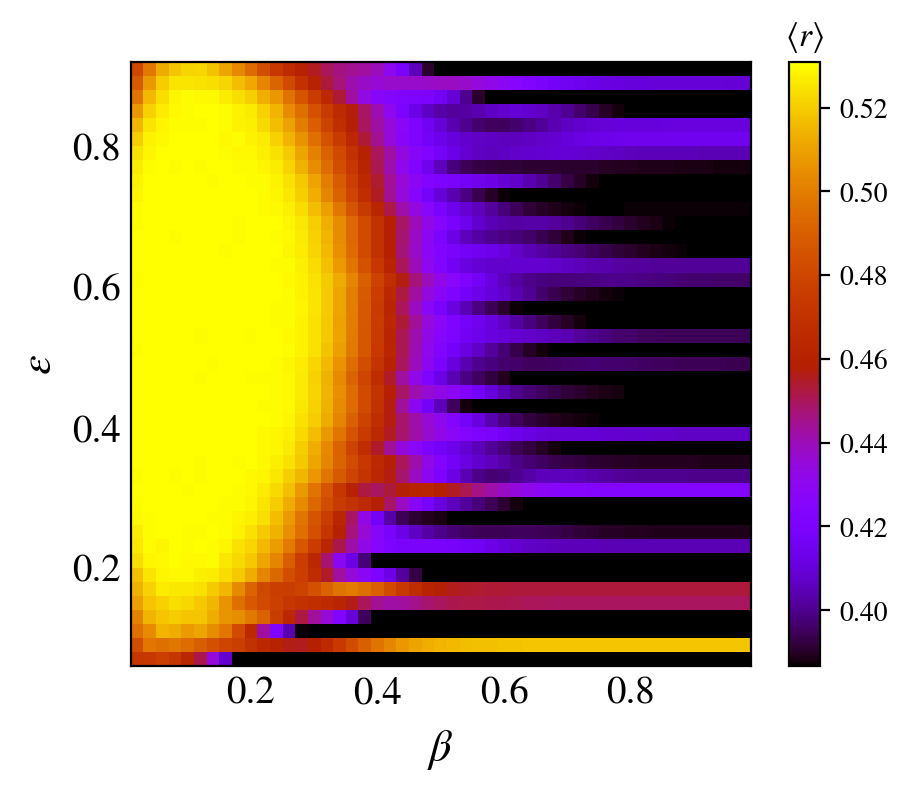

In [367]:

markers = itertools.cycle(markers_ls)


L = 16
w = 2
J = 1
delta=0.55
op=0


use_gap_or_weight = 1
BC = 1

prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
# prefix = '../results/disorder/OBC/Spectrals_SzSz_test/'
hz = 1 if BC else 0
if not BC: use_gap_or_weight = 1

sizes = np.arange(12, 18, 2)

wx_vals2 = np.sort( np.array([*np.arange(0.04, 1.01, 0.04), *np.arange(0.22, 0.61, 0.04), *np.arange(0.31, 0.51, 0.02)]) )
if BC:
    wx_vals2 = np.arange(0.02, 0.99, 0.02)
    # wx_vals2 = np.arange(0.2, 0.66, 0.05)
    # wx_vals2 = np.arange(0.2, 0.66, 0.02)


fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4), dpi = 200)

norm = matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])


energy_density = None
gap_ratio_density = []
for ii, wx in enumerate(wx_vals2):
    name = prefix + info_dis(L=L, J1=J, delta1=delta, w=wx, hz=hz) + '.hdf5'
    if exists(name):
        with h5py.File(name, "r") as file:
            # gap_ratio = np.array(file.get('gap_ratio density'))
            E = np.array(file.get('energy_density'))
            E = E[1:-1]
            gap_ratio = np.array(file.get('gap_ratio_density'))[1:-1] if use_gap_or_weight else np.array(file.get('weight_density'))[1:-1]
            # gap_ratio = (gap_ratio - 0.3867) / (0.5307 - 0.3867)
            gap_ratio_density.append(gap_ratio if use_gap_or_weight else 1-gap_ratio)
            energy_density = E
    else:
        print(name)

energy_density = np.array(energy_density)
gap_ratio_density = np.array(gap_ratio_density)

interaction = np.array([wx_vals2 for _ in energy_density])

#white = plt.get_cmap('seismic', 100)(0.5*np.ones(1))
upper = plt.get_cmap('gnuplot', 100)(np.linspace(0.0, 1.0, 100))
colors = np.vstack((upper))  

mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

X, Y = np.meshgrid(wx_vals2, energy_density)

print(X.shape, Y.shape, gap_ratio_density.shape)
if use_gap_or_weight: p = axis.pcolormesh(X, Y, np.transpose(gap_ratio_density), shading='nearest', cmap=mymap, vmin=0.3867 if BC else 0, vmax=0.5309, rasterized=True)
else:                 p = axis.pcolormesh(X, Y, np.transpose(gap_ratio_density), shading='nearest', cmap=mymap, vmax=1-0.8100699350, vmin=0, rasterized=True)
# p = axis.pcolormesh(X, Y, np.transpose(gap_ratio_density), shading='nearest')
fig_help.set_plot_elements(axis, ylabel=r"$\epsilon$", xlabel=r"$\beta$", font_size=14, set_legend=False)
# axis.set_title(r"$L=%d, N=%d, g_0=%.2f$"%(L, N, J), fontsize=16)

clb = fig.colorbar(p)
clb.solids.set_edgecolor("face")     # avoid white gridlines
clb.solids.set_rasterized(True)
clb.ax.set_title(r"$\langle r\rangle$" if use_gap_or_weight else r"$1-\langle q\rangle$")

# a = 1.05
# b = 0.45
# alfac = alfa_crit
# alfac = 1 / np.sqrt(2)
# x = np.linspace(0.04, 0.96, 1000)
# axis.plot(alfac * np.exp(a**2 * (x - 0.5)**2 / 4 / b*2), x, color='k', ls='-', lw=2, label=r"Eq. (B1)", rasterized=True)
# leg = fig_help.set_legend(axis, fontsize=14, loc='lower left', anchor=(0.0, 0.96), ncol=2)
# leg.set_rasterized(True)
# axis.set_ylim(0.05, 0.94)

# fig.savefig("plots_AGP/FigS2.pdf", bbox_inches = 'tight', pad_inches=0.02)
# fig.savefig("plots_AGP/FigS2.png", bbox_inches = 'tight', pad_inches=0.02)
# from PIL import Image
# fname = 'plots_AGP/FigS2.png'
# image = Image.open(fname).convert("L")
# arr = np.asarray(image)
# figura, ax_gray = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200, sharex=True)
# ax_gray.set_axis_off()
# ax_gray.imshow(arr, cmap='gray', vmin=0, vmax=255)



No handles with labels found to put in legend.


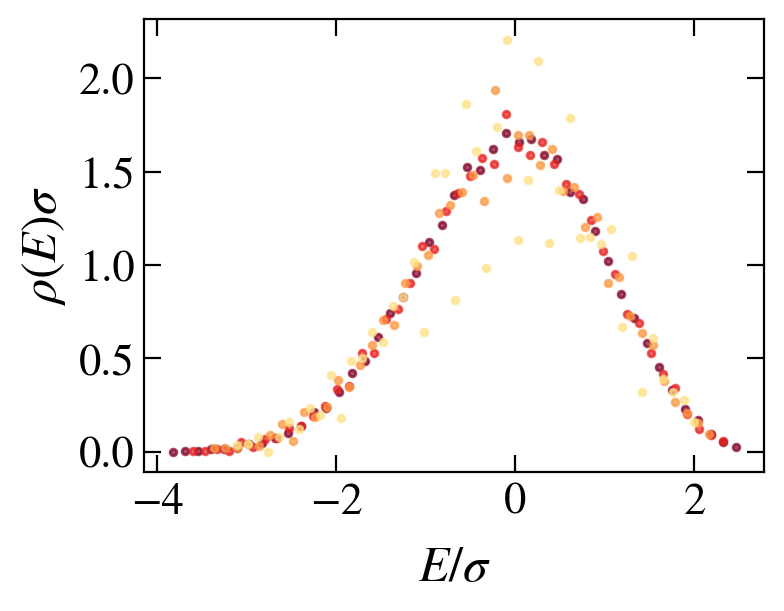

In [211]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

BC = 0

prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
hz = 1 if BC else 0

sizes = np.arange(12, 19, 2)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)

L = 15
eps = 0.5


norm = matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.2, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])


wx = 0.4
for iiL, L in enumerate(sizes[::-1]):
    dim = int( binom(L, L//2) )

    col = s_m.to_rgba(L)
    
    omegas = np.nan
    spec_fun = np.nan
    name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
    if exists(name):
        with h5py.File(name, "r") as file:
            Ex = np.array(file.get('energy_density')) * np.mean(np.array(file.get('bandwidth'))) + np.array(file.get('average energies'))[0]
            sig = np.mean(np.array(file.get('stddev')))
            Ex = Ex / sig
            DOS = np.array(file.get('DOS')) / dim / sig
            # print(Ex, DOS)
            axis.scatter(Ex, DOS, color=col, alpha=0.7, s=6)
    else:
        print(name)
    
    
fig_help.set_plot_elements(axis, ylabel=r"$\rho(E)\sigma$", xlabel=r"$E/\sigma$", font_size=16, set_legend=1, xscale='linear', yscale='linear')


fig.subplots_adjust(wspace = 0.02, hspace=0.02)

No handles with labels found to put in legend.


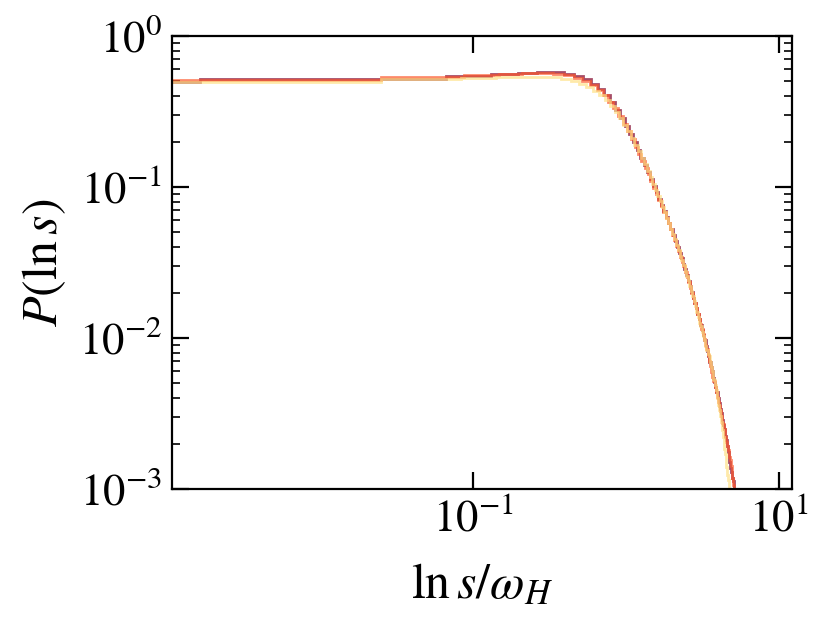

In [245]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

BC = 1

prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
hz = 1 if BC else 0

sizes = np.arange(12, 17, 2)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)

L = 15
eps = 0.5


norm = matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.2, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])


wx = 0.02
for iiL, L in enumerate(sizes[::-1]):
    dim = int( binom(L, L//2) )

    col = s_m.to_rgba(L)
    
    omegas = np.nan
    spec_fun = np.nan
    name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
    if exists(name):
        with h5py.File(name, "r") as file:
            wH = (np.array(file.get('wH')))[0]
            lvl_space_dist = np.array(file.get('lvl_spacing/dist_log'))
            lvl_space_bins = np.array(file.get('lvl_spacing/bins_log')) - np.log(wH)
            # print(Ex, DOS)
            axis.stairs(lvl_space_dist, lvl_space_bins, color=col, alpha=0.7)
    else:
        print(name)
    
    
fig_help.set_plot_elements(axis, ylabel=r"$P(\ln{s})$", xlabel=r"$\ln{s/\omega_H}$", font_size=16, set_legend=1, xscale='log', yscale='log')
axis.set_ylim(1e-3, 1e0)

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


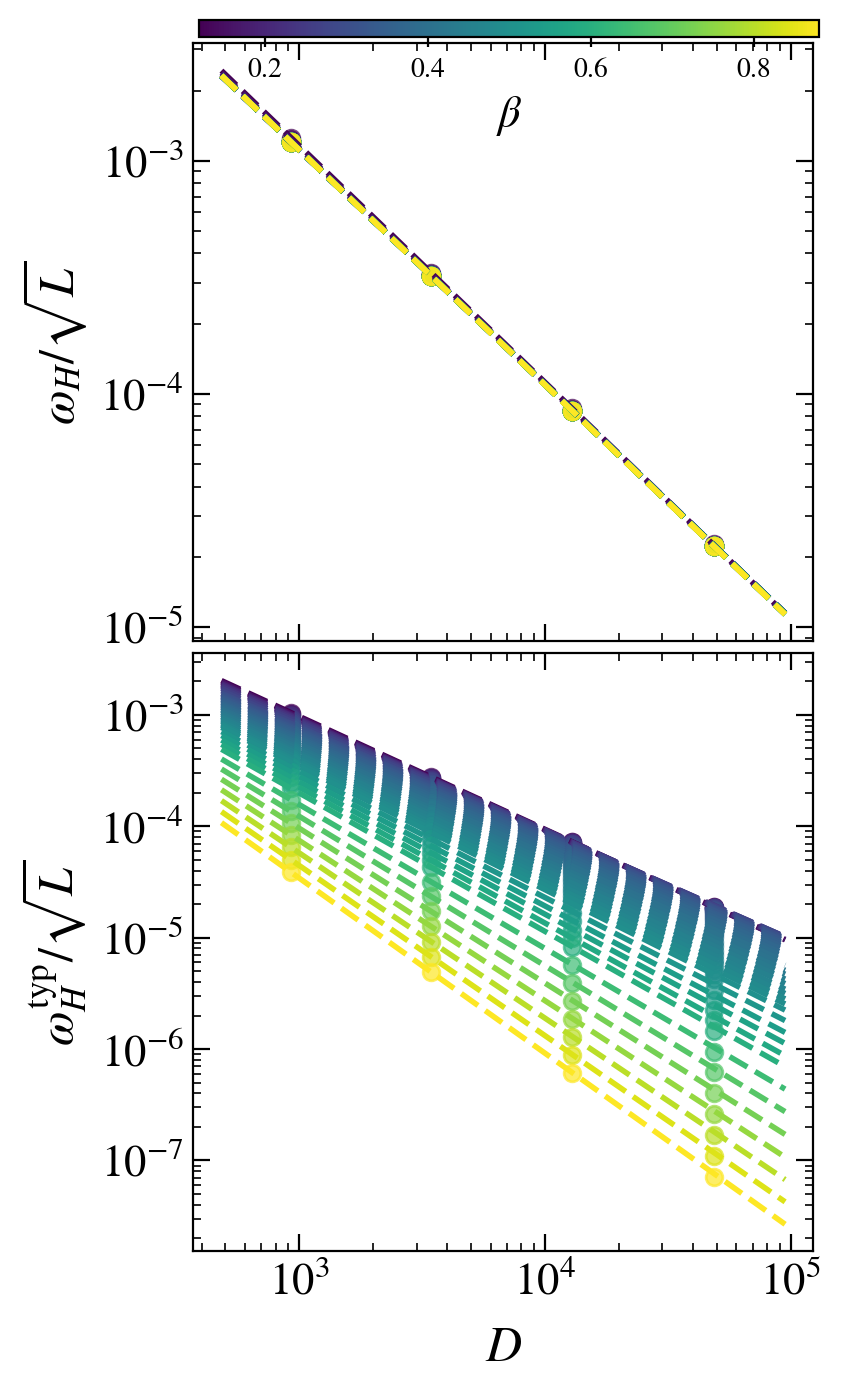

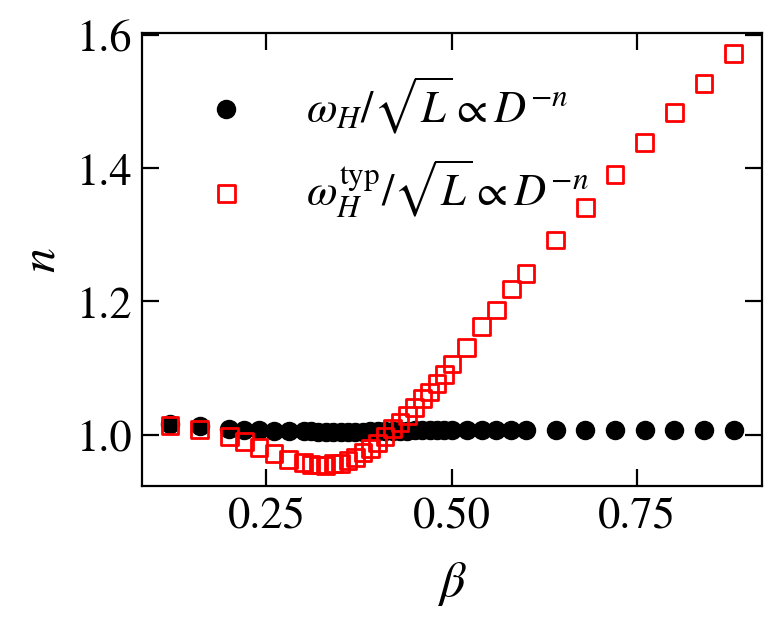

In [125]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

use_gap_or_weight = 0
BC = 0

prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
hz = 1 if BC else 0
if not BC: use_gap_or_weight = 1

sizes = np.arange(12, 18 if BC else 19, 2)

DIM = 1
fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,8), dpi = 200, sharex=True)
fig2, axis2 = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True)

r_idx = 5
corr = 0
gx = 1.5
window = 40

L = 15
eps = 0.5

def exp_fit_kurwa(x, a, xi):
    """Exponential function to fit and find decay rate"""
    return a * 2**(-x * xi)
    # return 1 - 1 / (1 + a * 2**(-x * xi))

wx_vals = np.arange(0.02, 0.99, 0.02) if BC else np.sort( np.array([*np.arange(0.12, 0.91, 0.04), *np.arange(0.22, 0.61, 0.04), *np.arange(0.31, 0.51, 0.02)]) )

norm = matplotlib.colors.Normalize(
        vmin=min(wx_vals),
        vmax=max(wx_vals))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])


def maj_fit(D, a, b):
    return a * D**(-b)
    
n_wH = []
n_wH_typ = []

dims = binom(sizes, sizes//2)
for ibsifusdf, wx in enumerate(wx_vals):
    col = s_m.to_rgba(wx)
    
    wH = np.zeros(sizes.shape)
    wH_typ = np.zeros(sizes.shape)
    realis = np.zeros(sizes.shape)
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    for iiL, L in enumerate(sizes):
        dim = int( binom(L, L//2) )
        counter = 0
        r = 0#np.zeros((45))
        
        name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                wH[iiL] = np.array(file.get('wH'))[-2] / L**0.5
                wH_typ[iiL] = np.array(file.get('wH_typ'))[-2] / L**0.5
                
                realis[iiL] = np.array(file.get('realisations'))
        else:
            print(name)
    
    for iiy, yy in enumerate([wH, wH_typ]):
        parsolo, pconv, fit_info, msg, _ = fit(maj_fit,
                        xdata = dims,
                        ydata = yy,
                        full_output=True, maxfev=20000)
        A = parsolo[0]
        n = parsolo[1]
        
        if iiy == 0: n_wH.append(n)
        else:        n_wH_typ.append(n)
        
        z = np.linspace(min(sizes)-1, max(sizes)+1, 1000)
        z = binom(z, z/2)
        axis[iiy].plot(z, maj_fit(z, *parsolo), color=col, ls='--', lw=2)
        axis[iiy].scatter(dims, yy, color=col, alpha=0.7)
    
cbar_ax = axis[0].inset_axes([0.01, 1.01, 1, 0.03])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
cbar.set_label(r"$\beta$", fontsize=16)


axis2.scatter(wx_vals, n_wH, color='black', marker='o', label=r'$\omega_H/\sqrt{L}\propto D^{-n}$')
axis2.scatter(wx_vals, n_wH_typ, color='red', marker='s', facecolor='None', label=r'$\omega_H^{\rm typ}/\sqrt{L}\propto D^{-n}$')

fig_help.set_plot_elements(axis[0], ylabel=r"$\omega_H/\sqrt{L}$", xlabel="", font_size=16, set_legend=1, xscale='log', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$\omega_H^{\rm typ}/\sqrt{L}$", xlabel=r"$D$", font_size=16, set_legend=1, xscale='log', yscale='log')
fig_help.set_plot_elements(axis2, ylabel=r"$n$", xlabel=r"$\beta$", font_size=16, set_legend=1, xscale='linear', yscale='linear')


fig.subplots_adjust(wspace = 0.02, hspace=0.02)

In [121]:
for L in range(12, 24, 2):
    print(L, binom(L, L//2), binom(L, L//2)**(-0.01))

12 924.0 0.9339922665464601
14 3432.0 0.9218166055374063
16 12870.0 0.9097126095739263
18 48620.0 0.8977012924562404
20 184756.0 0.8857966112430677
22 705432.0 0.8740080816756499


## SPECTRAL FUNCTIONS

No handles with labels found to put in legend.


../results/disorder/OBC/Spectrals_spin_current/_L=14,J1=1,J2=0,d1=0.55,d2=0,hz=1,w=0.2,pb=0.hdf5
../results/disorder/OBC/Spectrals_spin_current/_L=16,J1=1,J2=0,d1=0.55,d2=0,hz=1,w=0.2,pb=0.hdf5
../results/disorder/OBC/Spectrals_spin_current/_L=18,J1=1,J2=0,d1=0.55,d2=0,hz=1,w=0.2,pb=0.hdf5


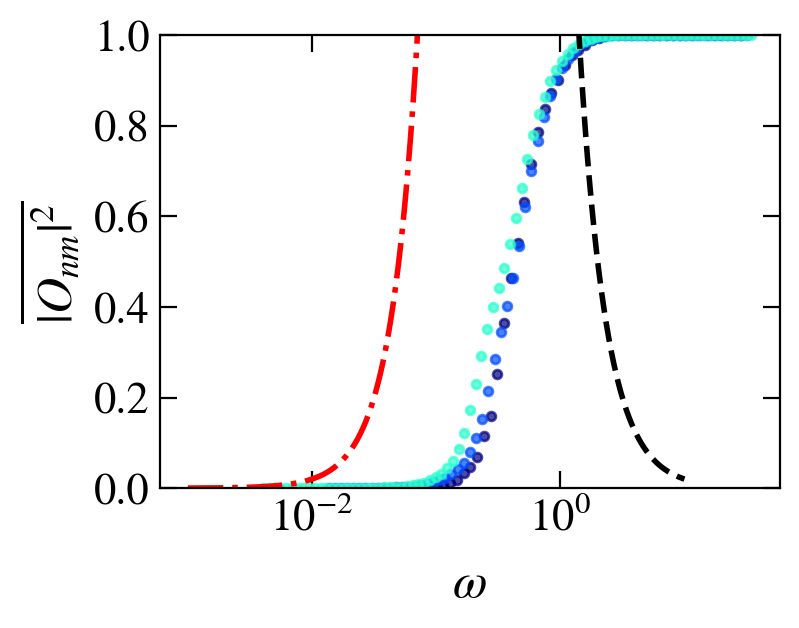

In [366]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

BC = 1

prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
prefix = '../results/disorder/OBC/Spectrals_spin_current/'
# prefix = '../results/disorder/OBC/Spectrals_energy_current/'
# prefix = '../results/disorder/OBC/Spectrals_Sz0/'
hz = 1 if BC else 0

sizes = np.arange(8, 19, 2)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)

L = 15
eps = 0.5


norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])


wx = 0.2
for iiL, L in enumerate(sizes):
    dim = int( binom(L, L//2) )

    col = s_m.to_rgba(L)
    
    omegas = np.nan
    spec_fun = np.nan
    name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
    if exists(name):
        with h5py.File(name, "r") as file:
            Ex = np.array(file.get('energy_density'))
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
            DOS = np.array(file.get('DOS'))[idx]
            wH = np.array(file.get('wH'))[0]
            
            G = 1#dim**(1-2*w) * L**2
            spec_fun = np.array(file.get('spec_fun'))[idx] * DOS * G
            spec_fun = np.array(file.get('int_spec_fun'))[idx]
            spec_fun = (spec_fun - spec_fun[0]) / (spec_fun[-1] - spec_fun[0])
            omegas = np.array(file.get('omegas'))[1:] / G
            
            realis = np.array(file.get('realisations'))
            axis.scatter(omegas[omegas > wH], spec_fun[omegas > wH], color=col, alpha=0.7, s=10)
    else:
        print(name)
    
    
fig_help.set_plot_elements(axis, ylabel=r"$\overline{|O_{nm}|^2}$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='linear')

z = np.logspace(-3, 1, 1000)
# axis.plot(z, 0.02/z, ls=':', color='k', lw=2)
axis.plot(z, 2e0/z**2, ls='--', color='k', lw=2)
axis.plot(z, 200*z**2, ls='-.', color='red', lw=2)

axis.set_ylim(0, 1)

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

No handles with labels found to put in legend.


../results/disorder/OBC/Spectrals_energy_current/_L=12,J1=1,J2=0,d1=0.55,d2=0,hz=0,w=0.04,pb=0.hdf5
../results/disorder/OBC/Spectrals_energy_current/_L=12,J1=1,J2=0,d1=0.55,d2=0,hz=0,w=0.12,pb=0.hdf5
../results/disorder/OBC/Spectrals_energy_current/_L=12,J1=1,J2=0,d1=0.55,d2=0,hz=0,w=0.2,pb=0.hdf5
../results/disorder/OBC/Spectrals_energy_current/_L=12,J1=1,J2=0,d1=0.55,d2=0,hz=0,w=0.28,pb=0.hdf5
../results/disorder/OBC/Spectrals_energy_current/_L=12,J1=1,J2=0,d1=0.55,d2=0,hz=0,w=0.36,pb=0.hdf5
../results/disorder/OBC/Spectrals_energy_current/_L=12,J1=1,J2=0,d1=0.55,d2=0,hz=0,w=0.44,pb=0.hdf5


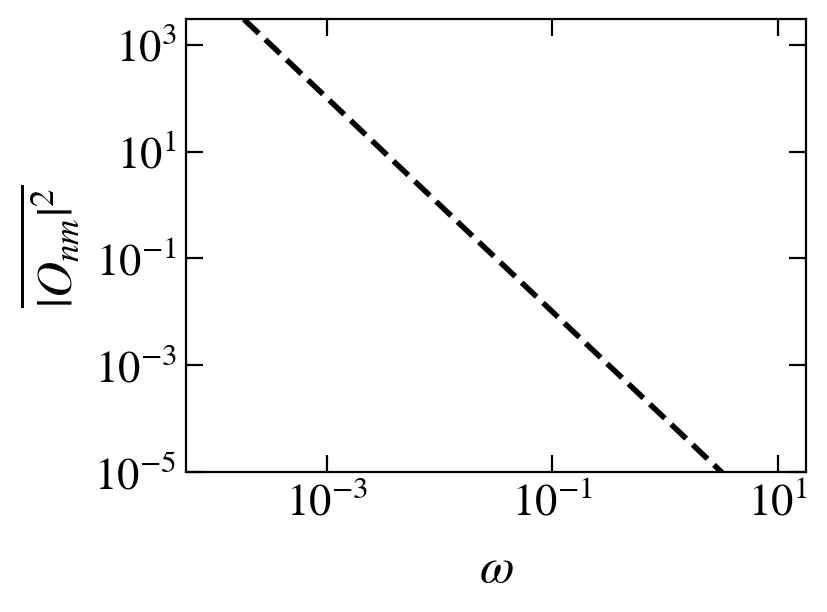

In [123]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

BC = 0

prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
prefix = '../results/disorder/OBC/Spectrals_energy_current/'
hz = 1 if BC else 0

sizes = np.arange(12, 19, 2)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)

L = 12
eps = 0.5

wx_vals = np.arange(0.04, 0.52, 0.08)
# wx_vals = np.arange(0.2, 0.52, 0.05)



norm = matplotlib.colors.Normalize(
        vmin=min(wx_vals),
        vmax=max(wx_vals))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])


wx = 0.2
for iiL, wx in enumerate(wx_vals):
    col = s_m.to_rgba(wx)
    
    omegas = np.nan
    spec_fun = np.nan
    name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
    if exists(name):
        with h5py.File(name, "r") as file:
            Ex = np.array(file.get('energy_density'))
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
            DOS = np.array(file.get('DOS'))[idx]
            wH = 0#np.array(file.get('wH'))[0]
            
            G = 1#dim**(1-2*w) * L**2
            spec_fun = np.array(file.get('spec_fun'))[idx] * DOS * G
            omegas = np.array(file.get('omegas'))[1:] / G
            
            realis = np.array(file.get('realisations'))
            axis.scatter(omegas[omegas > wH], spec_fun[omegas > wH], color=col, alpha=0.7, s=10)
    else:
        print(name)
    
    
    
fig_help.set_plot_elements(axis, ylabel=r"$\overline{|O_{nm}|^2}$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')

z = np.logspace(-4, 1, 1000)
# axis.plot(z, 0.02/z, ls=':', color='k', lw=2)
axis.plot(z, 0.0001/z**2, ls='--', color='k', lw=2)

axis.set_ylim(1e-5, 3e3)

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


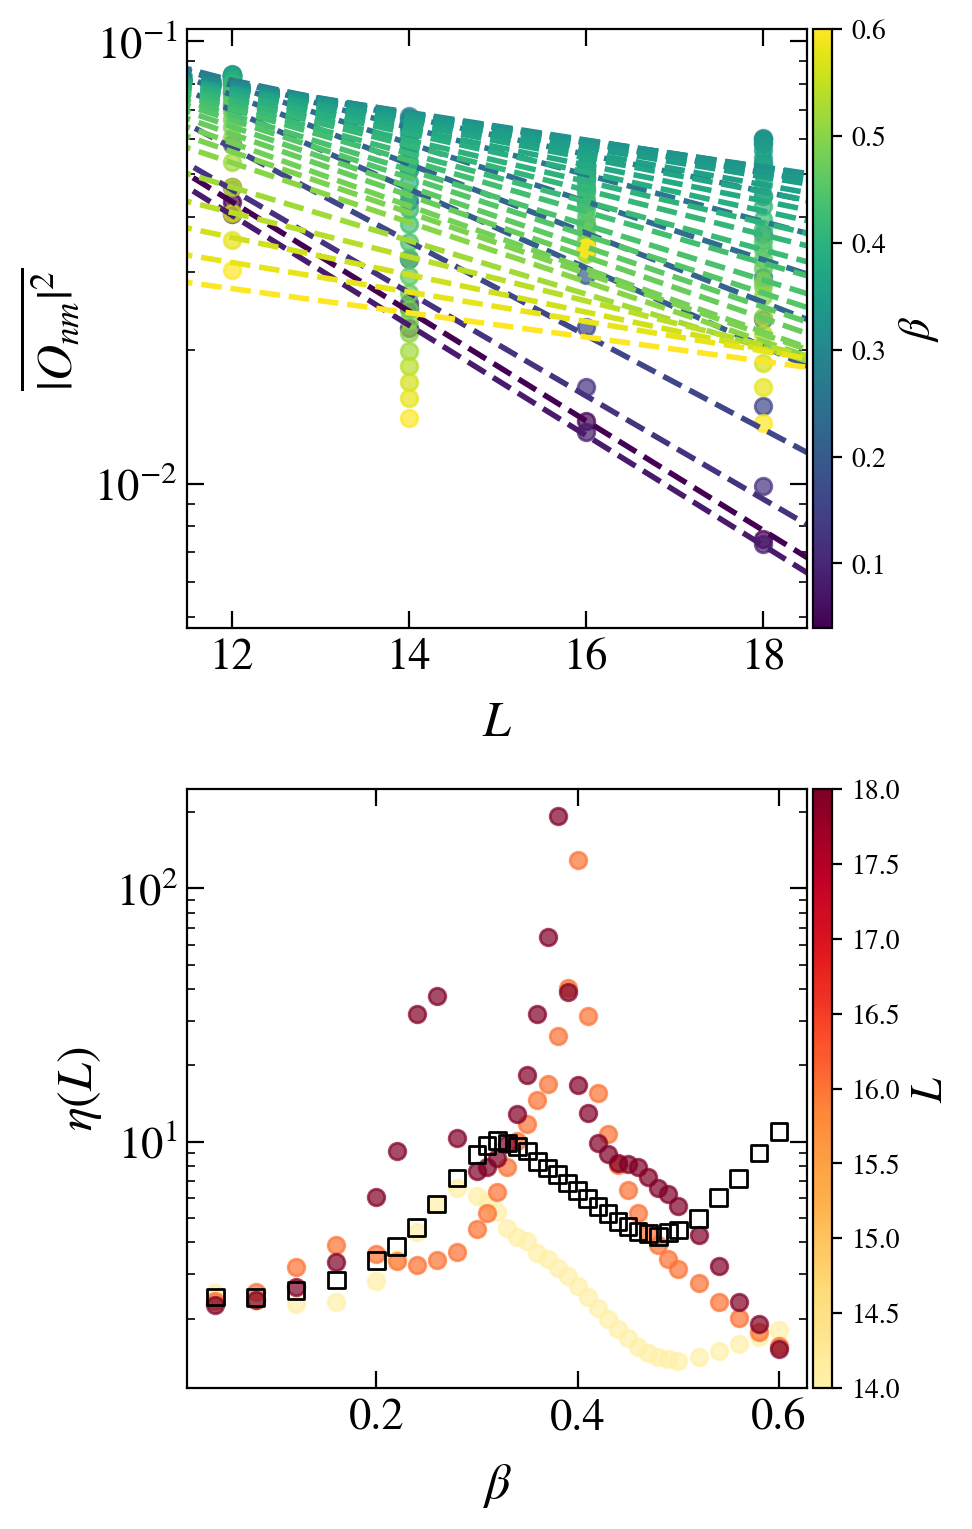

In [115]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

BC = 0

prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
hz = 1 if BC else 0

sizes = np.arange(12, 19, 2)

DIM = 1
fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,9), dpi = 200)


r_idx = 5
corr = 0
gx = 1.5
window = 40

L = 15
eps = 0.5

def exp_fit_kurwa(x, a, xi):
    """Exponential function to fit and find decay rate"""
    return a * 2**(-x * xi)
    # return 1 - 1 / (1 + a * 2**(-x * xi))

wx_vals = np.arange(0.2, 0.51, 0.02) if BC else np.sort( np.array([*np.arange(0.04, 0.61, 0.04), *np.arange(0.22, 0.61, 0.04), *np.arange(0.31, 0.51, 0.02)]) )

norm = matplotlib.colors.Normalize(
        vmin=min(wx_vals),
        vmax=max(wx_vals))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

etas = []
etas_fit = []
for ibsifusdf, wx in enumerate(wx_vals):
    col = s_m.to_rgba(wx)
    
    spec_fun_at_wh = np.zeros(sizes.shape)
    realis = np.zeros(sizes.shape)
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    for iiL, L in enumerate(sizes):
        dim = int( binom(L, L//2) )
        counter = 0
        r = 0#np.zeros((45))
        
        name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                DOS = np.array(file.get('DOS'))[idx]
                wH = np.array(file.get('wH'))[0]
                
                spec_fun = np.array(file.get('spec_fun'))[idx]
                omegas = np.array(file.get('omegas'))[1:]
                realis[iiL] = np.array(file.get('realisations'))
                
                idx_wH1 = np.argmin(np.abs( omegas - wH ))
                idx_wH2 = np.argmin(np.abs( omegas - 5*wH ))
                spec_fun_at_wh[iiL] = np.mean( np.sqrt(spec_fun[idx_wH1 : idx_wH2]) )
        else:
            print(name)
    
    # print(wx, realis, gap_ratio)
    yy = spec_fun_at_wh
    # print(gx, sizes, yy)
    parsolo, pconv, fit_info, msg, _ = fit(exp_fit_kurwa,
                    xdata = sizes,
                    ydata = yy,
                    full_output=True, maxfev=10000)
    A = parsolo[0]
    eta_fit = 1 / parsolo[1]
    if eta_fit > 1e6:
        eta_fit = np.nan
    etas_fit.append(eta_fit)
    # if (iig == 0 and gx > 1.0) or (iig and gx < 4):
    z = np.linspace(min(sizes)-1, max(sizes)+1, 1000)
    axis[0].plot(z, exp_fit_kurwa(z, *parsolo), color=col, ls='--', lw=2)
    axis[0].scatter(sizes, yy, color=col, alpha=0.7)
    
    eta = 1 / (np.diff( np.log(spec_fun_at_wh) ) / np.diff(sizes) / np.log(2))
    etas.append(eta)
    
cbar_ax = axis[0].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$\beta$", fontsize=16)
# cbar_ax.xaxis.set_ticks_position('top')
# cbar_ax.xaxis.set_label_position('top')

etas_fit = np.array(etas_fit)
etas = np.transpose(np.array(etas))

norm = matplotlib.colors.Normalize(vmin=min(sizes[1:]), vmax=max(sizes[1:]) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])
for iiL, L in enumerate(sizes[1:]):
    col = s_m.to_rgba(L)
    axis[1].scatter(wx_vals, np.abs(etas[iiL]), color=col, marker='o', facecolor=col, alpha=0.7)  

axis[1].scatter(wx_vals, np.abs(etas_fit), color='k', marker='s', facecolor='None')


axis[0].set_xlim(min(sizes)-0.5, max(sizes)+0.5)

cbar_ax = axis[1].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$L$", fontsize=16)

# ax.set_ylim(0, 1.05)

# z = np.linspace(1.0, 3.01, 1000)
# ax.plot(z, 2/np.abs(2 - z), ls='-.', color='blue')
# ax.set_ylim(1, 3e2)
# z = np.linspace(0.5, 1.0, 1000)
# ax.plot(z, [1]*z.size, ls='-.', color='blue')
# # ax[1].scatter(gamma_vals, 1/(etas_NE / np.log(2)), color='red', marker='s', facecolor='None')

fig_help.set_plot_elements(axis[0], ylabel=r"$\overline{|O_{nm}|^2}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
# fig_help.set_plot_elements(axis[1], ylabel=r"$\bar{r} - r_{\rm PE}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$\eta(L)$", xlabel=r"$\beta$", font_size=16, set_legend=1, xscale='linear', yscale='log')


fig.subplots_adjust(wspace = 0.27, hspace=0.27)

In [357]:
print(923**(-0.92) - 924**(-0.92))

1.862726524227542e-06


## TIME EVOLUTION

No handles with labels found to put in legend.


../results/disorder/OBC/Spectrals_energy_current/_L=14,J1=1,J2=0,d1=0.55,d2=0,hz=1,w=0.01,pb=0.hdf5
../results/disorder/OBC/Spectrals_energy_current/_L=16,J1=1,J2=0,d1=0.55,d2=0,hz=1,w=0.01,pb=0.hdf5


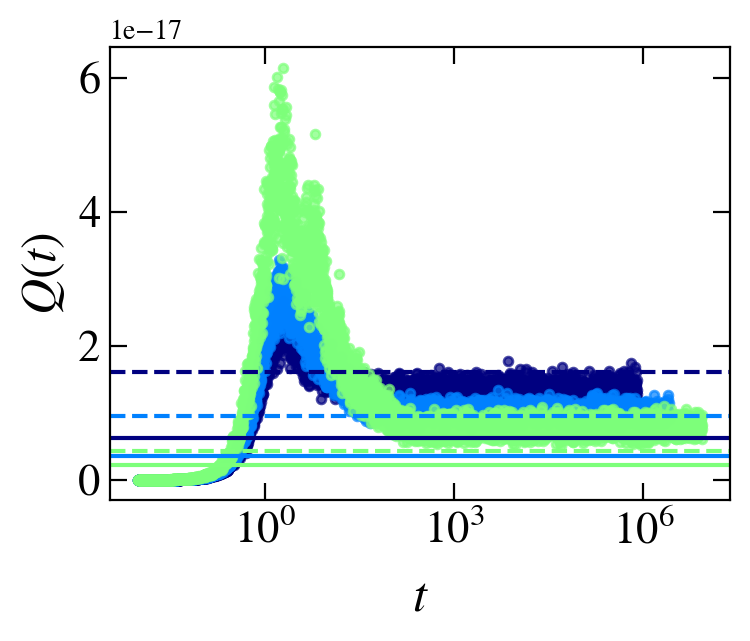

In [342]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'

BC = 1

prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
prefix = '../results/disorder/OBC/Spectrals_energy_current/'
hz = 1 if BC else 0

sizes = np.arange(8, 17, 2)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)

L = 15
eps = 0.5

wx_vals = np.arange(0.2, 8.21, 0.2)



norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])


wx = 0.01
for iiL, L in enumerate(sizes):
    dim = int( binom(L, L//2) )

    col = s_m.to_rgba(L)
    
    omegas = np.nan
    spec_fun = np.nan
    name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
    if exists(name):
        with h5py.File(name, "r") as file:
            Ex = np.array(file.get('energy_density'))
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
            DOS = np.array(file.get('DOS'))[idx]
            
            G = 1#dim**(1-2*w) * L**2
            spec_fun = np.array(file.get('quench'))
            omegas = np.array(file.get('times')) / G
            
            realis = np.array(file.get('realisations'))
            
            DE = np.array(file.get('diagonal ensemble abs'))
            axis.axhline(y=DE, color=col, ls='-')
            
            MC = np.array(file.get('microcanonical ensemble abs'))
            axis.axhline(y=MC, color=col, ls='--')
    else:
        print(name)
    
    axis.scatter(omegas, spec_fun, color=col, alpha=0.7, s=10)
    
    
fig_help.set_plot_elements(axis, ylabel=r"$Q(t)$", xlabel=r"$t$", font_size=16, set_legend=1, xscale='log', yscale='linear')

# axis.set_ylim(1e-3, 5e1)

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


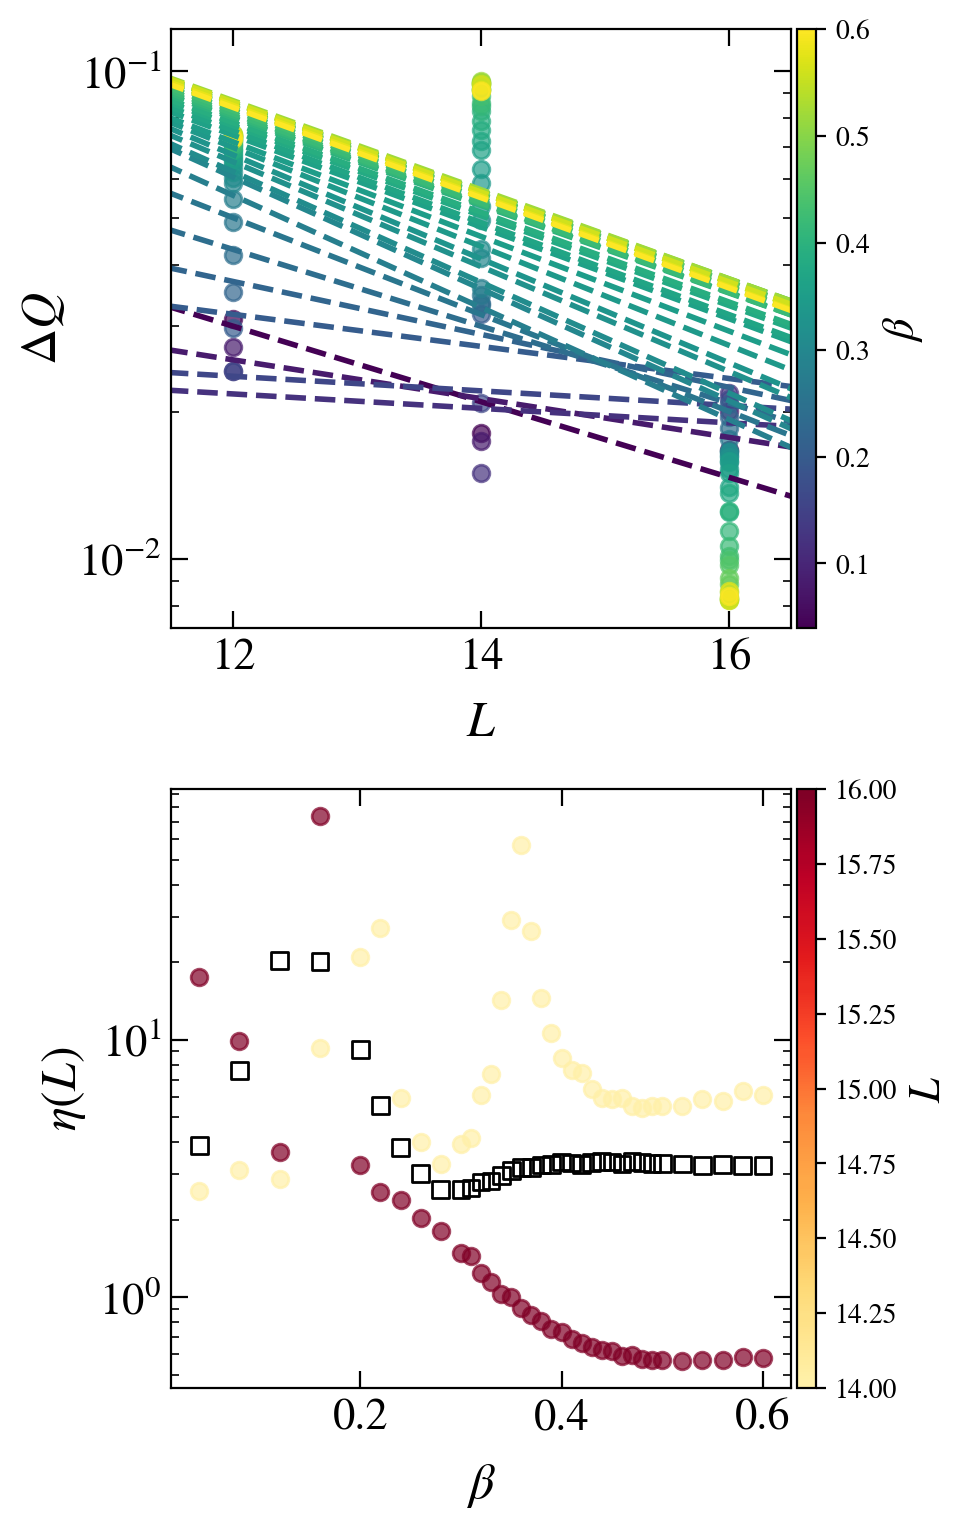

In [39]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

BC = 0

prefix = '../results/disorder/OBC/Spectrals_SzSz/' if BC else '../results/disorder/PBC/Spectrals_SzSz/'
hz = 1 if BC else 0

sizes = np.arange(12, 18, 2)

DIM = 1
fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,9), dpi = 200)


r_idx = 5
corr = 0
gx = 1.5
window = 40

L = 15
eps = 0.5

def exp_fit_kurwa(x, a, xi):
    """Exponential function to fit and find decay rate"""
    return a * 2**(-x * xi)
    # return 1 - 1 / (1 + a * 2**(-x * xi))

wx_vals = np.arange(0.2, 0.51, 0.02) if BC else np.sort( np.array([*np.arange(0.04, 0.61, 0.04), *np.arange(0.22, 0.61, 0.04), *np.arange(0.31, 0.51, 0.02)]) )

norm = matplotlib.colors.Normalize(
        vmin=min(wx_vals),
        vmax=max(wx_vals))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

etas = []
etas_fit = []
for ibsifusdf, wx in enumerate(wx_vals):
    col = s_m.to_rgba(wx)
    
    deltaQ = np.zeros(sizes.shape)
    realis = np.zeros(sizes.shape)
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    for iiL, L in enumerate(sizes):
        dim = int( binom(L, L//2) )
        counter = 0
        r = 0#np.zeros((45))
        
        name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                DOS = np.array(file.get('DOS'))[idx]
                wH = np.array(file.get('wH'))[0]
                
                deltaQ[iiL] = np.array(file.get('deltaQ'))
        else:
            print(name)
    
    # print(wx, realis, gap_ratio)
    yy = deltaQ
    # print(gx, sizes, yy)
    parsolo, pconv, fit_info, msg, _ = fit(exp_fit_kurwa,
                    xdata = sizes,
                    ydata = yy,
                    full_output=True, maxfev=10000)
    A = parsolo[0]
    eta_fit = 1 / parsolo[1]
    if eta_fit > 1e6:
        eta_fit = np.nan
    etas_fit.append(eta_fit)
    # if (iig == 0 and gx > 1.0) or (iig and gx < 4):
    z = np.linspace(min(sizes)-1, max(sizes)+1, 1000)
    axis[0].plot(z, exp_fit_kurwa(z, *parsolo), color=col, ls='--', lw=2)
    axis[0].scatter(sizes, yy, color=col, alpha=0.7)
    
    eta = 1 / (np.diff( np.log(deltaQ) ) / np.diff(sizes) / np.log(2))
    etas.append(eta)
    
cbar_ax = axis[0].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$\beta$", fontsize=16)
# cbar_ax.xaxis.set_ticks_position('top')
# cbar_ax.xaxis.set_label_position('top')

etas_fit = np.array(etas_fit)
etas = np.transpose(np.array(etas))

norm = matplotlib.colors.Normalize(vmin=min(sizes[1:]), vmax=max(sizes[1:]) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])
for iiL, L in enumerate(sizes[1:]):
    col = s_m.to_rgba(L)
    axis[1].scatter(wx_vals, np.abs(etas[iiL]), color=col, marker='o', facecolor=col, alpha=0.7)  

axis[1].scatter(wx_vals, np.abs(etas_fit), color='k', marker='s', facecolor='None')


axis[0].set_xlim(min(sizes)-0.5, max(sizes)+0.5)

cbar_ax = axis[1].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$L$", fontsize=16)

# ax.set_ylim(0, 1.05)

# z = np.linspace(1.0, 3.01, 1000)
# ax.plot(z, 2/np.abs(2 - z), ls='-.', color='blue')
# ax.set_ylim(1, 3e2)
# z = np.linspace(0.5, 1.0, 1000)
# ax.plot(z, [1]*z.size, ls='-.', color='blue')
# # ax[1].scatter(gamma_vals, 1/(etas_NE / np.log(2)), color='red', marker='s', facecolor='None')

fig_help.set_plot_elements(axis[0], ylabel=r"$\Delta Q$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
# fig_help.set_plot_elements(axis[1], ylabel=r"$\bar{r} - r_{\rm PE}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$\eta(L)$", xlabel=r"$\beta$", font_size=16, set_legend=1, xscale='linear', yscale='log')


fig.subplots_adjust(wspace = 0.27, hspace=0.27)